In [1]:
# @title
# ================================================================================
# PARTE 1: INSTALAÇÃO E IMPORTAÇÕES
# ================================================================================
# Este notebook implementa um modelo de otimização baseado no artigo científico:
# "Optimization-Based Operation of Distribution Grids With Residential Battery
#  Storage: Assessing Utility and Customer Benefits"
# Publicado na IEEE Transactions on Power Systems, Vol. 38, No. 1, Janeiro de 2023.
# O objetivo é otimizar o uso de baterias residenciais para minimizar custos e
# controlar a tensão na rede elétrica.
# ================================================================================

# --- Instalação de Bibliotecas (somente se necessário no ambiente do notebook) ---
# Instala as bibliotecas 'cvxpy', 'osqp' e 'ecos'.
# 'cvxpy' é uma biblioteca para modelagem e solução de problemas de otimização convexa.
# 'osqp' e 'ecos' são 'solvers' (resolvedores) que o CVXPY pode usar para encontrar a solução ótima.
# O comando `%pip install -q` garante uma instalação silenciosa (sem muita saída no console).
%pip install -q cvxpy osqp ecos

# --- Importações ---
# Importa módulos essenciais para o funcionamento do notebook:
import sys, platform, warnings, random
import numpy as np           # Para operações numéricas e arrays (ex: vetores, matrizes).
import pandas as pd          # Para manipulação e análise de dados (ex: DataFrames).
import matplotlib.pyplot as plt # Para criação de gráficos e visualizações.
import cvxpy as cp           # A biblioteca principal para definir e resolver problemas de otimização.

# --- Configuração Global ---
# Define parâmetros padrão para os gráficos gerados com Matplotlib, garantindo uma aparência consistente.
plt.rcParams.update({
    "figure.figsize": (12, 8), # Define o tamanho padrão das figuras (largura x altura em polegadas).
    "font.size": 11,           # Define o tamanho da fonte padrão para o texto dos gráficos.
    "axes.grid": True,         # Ativa as grades nos eixos dos gráficos.
    "axes.axisbelow": True,    # Garante que as linhas da grade sejam desenhadas abaixo dos outros elementos do gráfico.
    "figure.autolayout": True, # Ajusta automaticamente o layout da figura para evitar sobreposições.
})
# Configura as opções de impressão do NumPy para números de ponto flutuante, tornando-os mais legíveis.
np.set_printoptions(suppress=True, floatmode="maxprec_equal")
# Silencia avisos que são menos relevantes para a execução do notebook, mantendo a saída limpa.
warnings.filterwarnings("ignore", category=UserWarning)

# Reprodutibilidade: Define uma semente para geradores de números aleatórios.
# Isso garante que os resultados que dependem de aleatoriedade sejam os mesmos a cada execução.
SEED = 42
_rng = np.random.default_rng(SEED)
random.seed(SEED)

# --- Diagnóstico de Ambiente e Solvers ---
# Verifica quais 'solvers' de otimização estão instalados e disponíveis para o CVXPY.
available_solvers = cp.installed_solvers()
# Define uma ordem de preferência para os 'solvers' a serem utilizados.
preferred_order = ["OSQP", "ECOS", "CLARABEL", "SCS"]
# Seleciona o primeiro 'solver' preferido que estiver disponível.
chosen_solver = next((s for s in preferred_order if s in available_solvers), None)

# Imprime informações sobre o ambiente e os 'solvers' detectados.
print("="*80)
print("PARTE 1: CONFIGURAÇÃO INICIAL")
print("="*80)
print(f"Python: {platform.python_version()}  |  Plataforma: {platform.platform()}")
print(f"Numpy: {np.__version__}  |  Pandas: {pd.__version__}  |  CVXPY: {cp.__version__}")
print(f"\n✓ Bibliotecas importadas com sucesso")
print(f"✓ Solvers disponíveis: {available_solvers}")
print(f"✓ Solver preferido detectado: {chosen_solver if chosen_solver else 'nenhum dos preferidos (usaremos fallback)'}")
print("="*80)

# Opcional: helper para resolver QP com fallback de solver (usaremos nas próximas células)
# Esta função tenta resolver um problema de otimização convexa (QP) usando os 'solvers' preferidos.
# Se um 'solver' falhar, ele tenta o próximo na lista, e depois qualquer outro disponível.
def solve_qp_with_fallback(problem: cp.Problem, verbose: bool = False):
    """
    Tenta resolver um QP usando ordem de solvers preferidos, com fallback.
    Retorna o status final da solução (ex: 'optimal', 'infeasible').
    """
    # Tenta resolver com os solvers na ordem preferida
    for s in preferred_order:
        if s in available_solvers:
            try:
                problem.solve(solver=getattr(cp, s), verbose=verbose) # Tenta resolver com o solver atual
                if problem.status in ("optimal", "optimal_inaccurate"): # Verifica se a solução foi encontrada
                    return problem.status # Retorna o status se bem-sucedido
            except Exception as ex:
                # Em caso de erro, ignora e tenta o próximo solver
                continue
    # Se nenhum dos preferidos funcionou, tenta com qualquer outro solver disponível
    for s in available_solvers:
        try:
            problem.solve(solver=getattr(cp, s), verbose=verbose)
            if problem.status in ("optimal", "optimal_inaccurate"):
                return problem.status
        except Exception:
            continue
    # Se nenhum solver conseguiu resolver, retorna o status final (provavelmente um erro)
    return problem.status

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 7.7 MB/s eta 0:00:00
PARTE 1: CONFIGURAÇÃO INICIAL
Python: 3.12.12  |  Plataforma: Linux-6.6.105+-x86_64-with-glibc2.35
Numpy: 2.0.2  |  Pandas: 2.2.2  |  CVXPY: 1.6.7

✓ Bibliotecas importadas com sucesso
✓ Solvers disponíveis: ['CLARABEL', 'CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']
✓ Solver preferido detectado: OSQP


In [2]:
#================================================================================
# PARTE 2: PARÂMETROS DO SISTEMA
#================================================================================
# Referência: Paper Seção IV (página 224)
# Observação crítica: As equações (21) e (31) operam naturalmente em p.u.
# Portanto, definimos bases (V_base e S_base) e convertemos R/X (Ω) -> p.u.
# e potências (kW/kvar) -> p.u. quando necessário.
#================================================================================

print("="*80)
print("PARTE 2: PARÂMETROS DO SISTEMA")
print("="*80)

# ==============================================================================
# PARÂMETROS TEMPORAIS
# ==============================================================================
DELTA = 5 / 60      # Intervalo de tempo: 5 minutos = 5/60 horas
T = 24              # Horizonte: 24 horas
K = int(T / DELTA)  # Número de amostras: 288

# Vetor de tempo [horas]
t = np.arange(K) * DELTA

print(f"\n⏱️  TEMPORAL:")
print(f"    Δ = 5 min = {DELTA:.4f} h")
print(f"    T = {T} h")
print(f"    K = {K} amostras")

# ==============================================================================
# PARÂMETROS DA BATERIA (Paper: página 224)
# "5 kW, 10 kWh residential battery"
# ==============================================================================
P_BAT_MAX = 5.0     # ū: Potência máxima de carga [kW]
P_BAT_MIN = -5.0    # -u: Potência máxima de descarga [kW]
E_BAT_MAX = 10.0    # s̄: Capacidade máxima [kWh]
E_BAT_MIN = 0.0     # Capacidade mínima [kWh]
SOC_0 = 2.0         # s₀: Estado de carga inicial [kWh]
SOC_F = 2.0         # sf: Estado de carga final [kWh]

print(f"\n🔋 BATERIA:")
print(f"    Potência: [{P_BAT_MIN}, +{P_BAT_MAX}] kW")
print(f"    Capacidade: {E_BAT_MAX} kWh")
print(f"    SOC inicial/final: {SOC_0} -> {SOC_F} kWh")

# ==============================================================================
# PARÂMETROS DO INVERSOR (Paper: página 224)
# "6 kVA inverter", "dispatchable reactive power limit is 3.3 kvar"
# ==============================================================================
S_INVERSOR = 6.0    # Potência aparente nominal [kVA]
# Limite reativo para o L-QP (paper usa 3.3 kvar)
Q_BAT_MAX_LQP = 3.3
Q_BAT_MIN_LQP = -3.3
# Limite reativo para o volt-var IEEE 1547 (44% da potência aparente)
Q_IEEE1547 = 0.44 * S_INVERSOR  # = 2.64 kvar

print(f"\n⚡ INVERSOR:")
print(f"    S nominal: {S_INVERSOR} kVA")
print(f"    Q máx (L-QP): ±{Q_BAT_MAX_LQP} kvar")
print(f"    Q máx (IEEE 1547 - volt-var): ±{Q_IEEE1547:.2f} kvar")

# ==============================================================================
# BASES ELÉTRICAS E PARÂMETROS DA REDE
# ==============================================================================
# IEEE 13NF: tensão nominal L-L ~ 4.16 kV -> L-N ~ 2.4 kV (paper usa 2.4 kV)
V_NOM = 1.0         # Vr: Tensão nominal [p.u.]
V_BASE_LN = 2400.0  # Tensão base fase-neutro [V] (2.4 kV L-N)
# Base de potência por fase (defina conforme seu caso; 1000 kVA por fase é um bom default
# para converter kW/kvar de cliente em p.u. de forma estável em testes locais).
S_BASE_KVA_PHASE = 1000.0       # [kVA] por fase (ajustável)
S_BASE_VA_PHASE = S_BASE_KVA_PHASE * 1e3

# Impedâncias equivalentes do caminho (Ω) até o nó 0 (exemplo; ajuste conforme seus dados)
R_LINHA_OHM = 0.10   # Rmm [Ω]
X_LINHA_OHM = 0.25   # Xmm [Ω]
# Z_base (monofásico): V_base^2 / S_base
Z_BASE_OHM = (V_BASE_LN**2) / S_BASE_VA_PHASE
RMM_PU = R_LINHA_OHM / Z_BASE_OHM
XMM_PU = X_LINHA_OHM / Z_BASE_OHM

print(f"\n🔌 REDE / BASES:")
print(f"    V_base (L-N) = {V_BASE_LN/1000:.3f} kV | S_base(fase) = {S_BASE_KVA_PHASE:.1f} kVA")
print(f"    Z_base = {Z_BASE_OHM:.4f} Ω")
print(f"    Rmm = {R_LINHA_OHM:.3f} Ω -> {RMM_PU:.5f} p.u.")
print(f"    Xmm = {X_LINHA_OHM:.3f} Ω -> {XMM_PU:.5f} p.u.")
print(f"    R/X(Ω) = {R_LINHA_OHM/X_LINHA_OHM:.2f}")

# Helpers de conversão potência <-> p.u. (usaremos quando necessário)
KW_BASE = S_BASE_KVA_PHASE       # 1 kVA ~ 1 kW para base
KVAR_BASE = S_BASE_KVA_PHASE

def kw_to_pu(p_kw: np.ndarray | float) -> np.ndarray | float:
    return np.asarray(p_kw) / KW_BASE

def kvar_to_pu(q_kvar: np.ndarray | float) -> np.ndarray | float:
    return np.asarray(q_kvar) / KVAR_BASE

def pu_to_kw(p_pu: np.ndarray | float) -> np.ndarray | float:
    return np.asarray(p_pu) * KW_BASE

def pu_to_kvar(q_pu: np.ndarray | float) -> np.ndarray | float:
    return np.asarray(q_pu) * KVAR_BASE

# ==============================================================================
# PARÂMETROS DE OTIMIZAÇÃO (Paper usa σ ≈ 0.01; aqui deixamos ajustável)
# ==============================================================================
SIGMA = 0.01        # Peso para regulação de tensão no L-QP (padrão paper)
ALPHA_RHO = 1.0     # Fator de segurança para ρ (se <1, reduz interação entre inverters)
V_THR = 1.10        # Vt para o cálculo de Et = Vr^2 - Vt^2

print(f"\n⚙️  OTIMIZAÇÃO:")
print(f"    σ (peso tensão) = {SIGMA}")
print(f"    α (fator de segurança do ρ) = {ALPHA_RHO}")
print(f"    V_t (limite superior p.u.) = {V_THR}")

# ==============================================================================
# FATOR DE POTÊNCIA (Paper: mean ~0.86 no IEEE 13NF)
# ==============================================================================
PF = 0.86
TAN_PHI = float(np.tan(np.arccos(PF)))

print(f"\n📐 FATOR DE POTÊNCIA:")
print(f"    PF médio = {PF}")
print(f"    tan(φ) = {TAN_PHI:.4f}")

print("\n" + "="*80)
print("✓ Parâmetros configurados com sucesso!")
print("="*80)


PARTE 2: PARÂMETROS DO SISTEMA

⏱️  TEMPORAL:
    Δ = 5 min = 0.0833 h
    T = 24 h
    K = 288 amostras

🔋 BATERIA:
    Potência: [-5.0, +5.0] kW
    Capacidade: 10.0 kWh
    SOC inicial/final: 2.0 -> 2.0 kWh

⚡ INVERSOR:
    S nominal: 6.0 kVA
    Q máx (L-QP): ±3.3 kvar
    Q máx (IEEE 1547 - volt-var): ±2.64 kvar

🔌 REDE / BASES:
    V_base (L-N) = 2.400 kV | S_base(fase) = 1000.0 kVA
    Z_base = 5.7600 Ω
    Rmm = 0.100 Ω -> 0.01736 p.u.
    Xmm = 0.250 Ω -> 0.04340 p.u.
    R/X(Ω) = 0.40

⚙️  OTIMIZAÇÃO:
    σ (peso tensão) = 0.01
    α (fator de segurança do ρ) = 1.0
    V_t (limite superior p.u.) = 1.1

📐 FATOR DE POTÊNCIA:
    PF médio = 0.86
    tan(φ) = 0.5934

✓ Parâmetros configurados com sucesso!


PARTE 3: PERFIS DE CARGA E PV

📊 CARGA ATIVA d(k):
    Mínimo: 0.46 kW | Máximo: 1.52 kW | Média: 0.76 kW

☀️  GERAÇÃO PV g(k):
    Mínimo (pico de geração): -2.02 kW | Máximo: -0.00 kW
    Pico PV: 2.02 kW (≈ meio-dia)

⚡ CARGA REATIVA e(k):
    Mínimo: 0.27 kvar | Máximo: 0.90 kvar

🔎 TENSÃO Vm(k):
    Mínimo: 0.980 p.u. | Máximo: 1.033 p.u. | Média: 1.005 p.u.


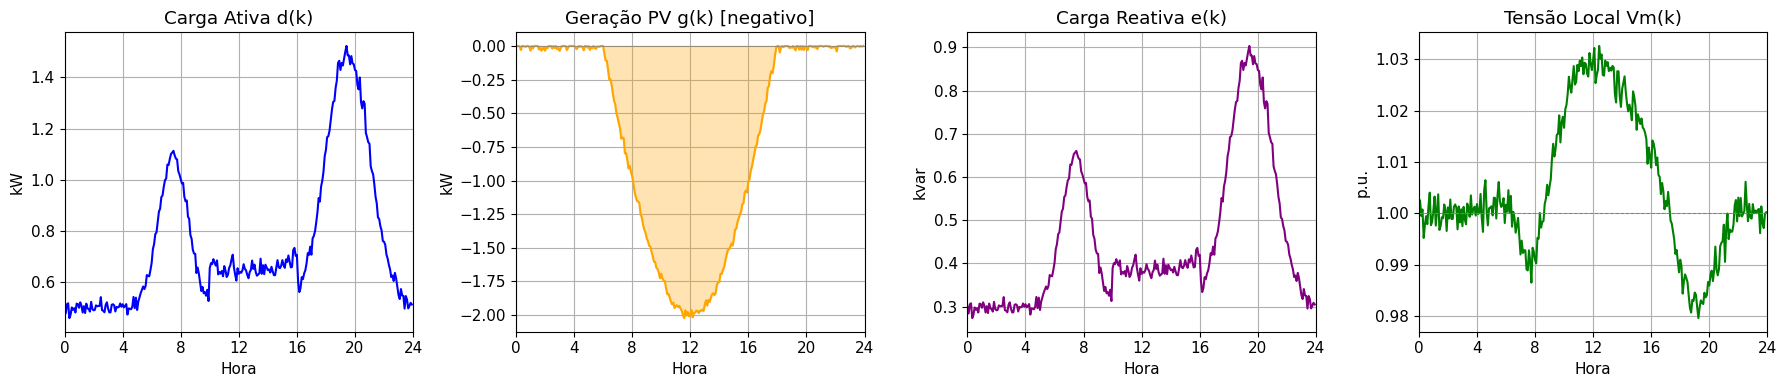


✓ Gráfico salvo: parte3_perfis.png


In [3]:
#================================================================================
# PARTE 3: PERFIS DE CARGA E GERAÇÃO PV
#================================================================================
# Referência: Paper Seção IV e Fig. 5 (página 225)
"""
Convenções do Paper (Equações 7 e 8):
- d(k) ≥ 0 : Carga ativa [kW] - sempre positiva
- g(k) ≤ 0 : Geração PV [kW] - sempre negativa (injeção)
- e(k) ≥ 0 : Carga reativa [kvar] - sempre positiva
"""
print("="*80)
print("PARTE 3: PERFIS DE CARGA E PV")
print("="*80)

# -------------------------------------------------------------------------------
# CARGA ATIVA d(k) [kW]
# -------------------------------------------------------------------------------
# Componentes: base + pico manhã + pico noite + atividade leve diurna + ruído
d_base = 0.5 * np.ones(K)
d_morning = 0.6 * np.exp(-0.5 * ((t - 7.5) / 1.0)**2)
d_evening = 1.0 * np.exp(-0.5 * ((t - 19.5) / 1.5)**2)
d_daylight = 0.15 * ((t >= 10) & (t <= 16)).astype(float)
d_noise = 0.02 * _rng.normal(size=K)

d_kw = d_base + d_morning + d_evening + d_daylight + d_noise
d_kw = np.clip(d_kw, 0.3, None)  # evita valores muito baixos

print(f"\n📊 CARGA ATIVA d(k):")
print(f"    Mínimo: {d_kw.min():.2f} kW | Máximo: {d_kw.max():.2f} kW | Média: {d_kw.mean():.2f} kW")

# -------------------------------------------------------------------------------
# GERAÇÃO PV g(k) [kW] — NEGATIVA (injeção) conforme Eq. (7)
# -------------------------------------------------------------------------------
pv_mag = np.zeros(K)
mask_day = (t >= 6) & (t <= 18)
pv_mag[mask_day] = 2.0 * np.sin(np.pi * (t[mask_day] - 6) / 12)  # pico ~ 2.0 kW ao meio-dia
pv_mag += 0.02 * _rng.normal(size=K)  # nuvens
pv_mag = np.clip(pv_mag, 0.0, 2.5)
g_kw = -pv_mag  # negativo por convenção

print(f"\n☀️  GERAÇÃO PV g(k):")
print(f"    Mínimo (pico de geração): {g_kw.min():.2f} kW | Máximo: {g_kw.max():.2f} kW")
print(f"    Pico PV: {pv_mag.max():.2f} kW (≈ meio-dia)")

# -------------------------------------------------------------------------------
# CARGA REATIVA e(k) [kvar] — baseada no PF médio (sempre ≥ 0)
# -------------------------------------------------------------------------------
e_kvar = np.maximum(d_kw * TAN_PHI, 0.0)

print(f"\n⚡ CARGA REATIVA e(k):")
print(f"    Mínimo: {e_kvar.min():.2f} kvar | Máximo: {e_kvar.max():.2f} kvar")

# -------------------------------------------------------------------------------
# TENSÃO LOCAL Vm(k) [p.u.] — sintética para L-QP (Eq. 21)
# Afundamentos 7–9h e 17–20h; elevação ao meio-dia; pequeno ruído
# -------------------------------------------------------------------------------
Vm = (
    1.0
    + 0.03 * np.exp(-0.5 * ((t - 12.0) / 3.0)**2)   # elevação com PV ao meio-dia
    - 0.02 * np.exp(-0.5 * ((t - 8.0) / 1.0)**2)    # afundamento manhã
    - 0.02 * np.exp(-0.5 * ((t - 19.0) / 1.2)**2)   # afundamento noite
    + 0.002 * _rng.normal(size=K)                   # ruído leve
)
Vm = np.clip(Vm, 0.94, 1.08)

print(f"\n🔎 TENSÃO Vm(k):")
print(f"    Mínimo: {Vm.min():.3f} p.u. | Máximo: {Vm.max():.3f} p.u. | Média: {Vm.mean():.3f} p.u.")

# -------------------------------------------------------------------------------
# OPCIONAL: Converter para p.u. (útil para L-QP com Rmm/Xmm em p.u.)
# -------------------------------------------------------------------------------
d_pu = kw_to_pu(d_kw)
g_pu = kw_to_pu(g_kw)       # negativo
e_pu = kvar_to_pu(e_kvar)   # positivo

# -------------------------------------------------------------------------------
# VISUALIZAÇÃO
# -------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=False)

ax = axes[0]
ax.plot(t, d_kw, 'b-', lw=1.5)
ax.set_xlabel('Hora'); ax.set_ylabel('kW')
ax.set_title('Carga Ativa d(k)')
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))

ax = axes[1]
ax.plot(t, g_kw, color='orange', lw=1.5)
ax.fill_between(t, g_kw, 0, alpha=0.3, color='orange')
ax.set_xlabel('Hora'); ax.set_ylabel('kW')
ax.set_title('Geração PV g(k) [negativo]')
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.axhline(0, color='gray', lw=0.5)

ax = axes[2]
ax.plot(t, e_kvar, 'purple', lw=1.5)
ax.set_xlabel('Hora'); ax.set_ylabel('kvar')
ax.set_title('Carga Reativa e(k)')
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))

ax = axes[3]
ax.plot(t, Vm, 'g-', lw=1.5)
ax.set_xlabel('Hora'); ax.set_ylabel('p.u.')
ax.set_title('Tensão Local Vm(k)')
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.axhline(1.0, color='gray', lw=0.7, ls='--')

plt.tight_layout()
plt.savefig('parte3_perfis.png', dpi=150)
plt.show()

print("\n✓ Gráfico salvo: parte3_perfis.png")
print("="*80)


PARTE 4: TARIFA TOU

💰 TARIFA TOU definida (vetor η de tamanho 288).
  - Fora de ponta: $0.032/kWh (00h-07h, 22h-24h)
  - Ponta:         $0.144/kWh (07h-09h, 17h-20h)
  - Intermediário: $0.065/kWh (09h-17h, 20h-22h)

🧪 Conjuntos de pesos preparados para varredura (Fig. 8):
  - Set1: sigma=0.010, zeta=(0.032..0.144)
  - Set2: sigma=0.010, zeta=(0.048..0.216)
  - Set3: sigma=0.020, zeta=(0.064..0.288)


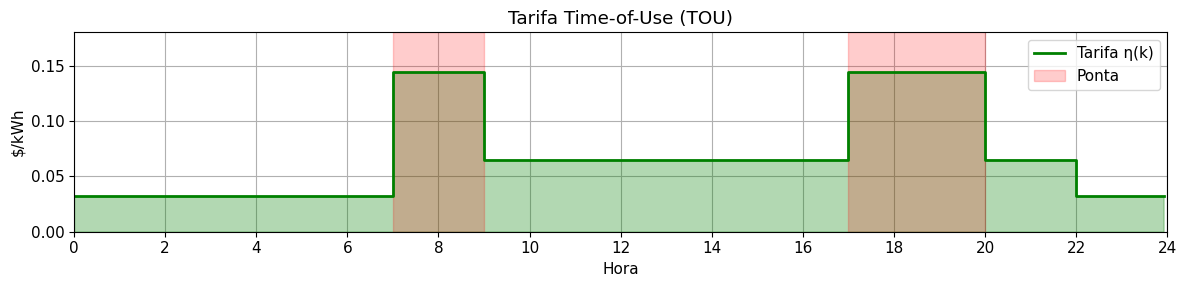


✓ Gráfico salvo: parte4_tarifa.png


In [4]:
# @title
# ================================================================================
# PARTE 4: TARIFA TIME-OF-USE (TOU)
# ================================================================================
# Referência: Paper Seção IV (página 224)
"""
Tarifa TOU (η):
- $0.032/kWh : 00h-07h e 22h-24h
- $0.144/kWh : 07h-09h e 17h-20h
- $0.065/kWh : 09h-17h e 20h-22h

Pesos do L-QP:
- ζ(k) = η(k) (default no paper)
- σ(k) = constante (default 0.01)

Aqui deixamos preparado para três conjuntos de pesos (Set 1–3) usados na Fig. 8:
- Set 1: σ = 0.01, ζ = 1.0 · η
- Set 2: σ = 0.01, ζ = 1.5 · η   (ζ maior)
- Set 3: σ = 0.02, ζ = 2.0 · η   (σ e ζ maiores)
Você pode ajustar os fatores conforme desejar.
"""
print("="*80)
print("PARTE 4: TARIFA TOU")
print("="*80)

def build_tou(t_vec: np.ndarray) -> np.ndarray:
    """Cria vetor η(k) (USD/kWh) para o dia, conforme janelas TOU."""
    hour = t_vec % 24
    eta_out = np.full_like(t_vec, 0.065, dtype=float)  # intermediário default
    off = (hour < 7) | (hour >= 22)
    peak = ((hour >= 7) & (hour < 9)) | ((hour >= 17) & (hour < 20))
    eta_out[off] = 0.032
    eta_out[peak] = 0.144
    return eta_out

eta = build_tou(t)
zeta = eta.copy()  # default: ζ(k) = η(k)

print(f"\n💰 TARIFA TOU definida (vetor η de tamanho {len(eta)}).")
print("  - Fora de ponta: $0.032/kWh (00h-07h, 22h-24h)")
print("  - Ponta:         $0.144/kWh (07h-09h, 17h-20h)")
print("  - Intermediário: $0.065/kWh (09h-17h, 20h-22h)")

# -------------------------------------------------------------------------------
# Conjuntos de pesos para varredura (Fig. 8)
# -------------------------------------------------------------------------------
SIGMA_SET1 = 0.01
SIGMA_SET2 = 0.01
SIGMA_SET3 = 0.02

ZETA_FACT_SET1 = 1.0
ZETA_FACT_SET2 = 1.5
ZETA_FACT_SET3 = 2.0

weights_sets = {
    "Set1": {"sigma": np.full(K, SIGMA_SET1), "zeta": ZETA_FACT_SET1 * eta},
    "Set2": {"sigma": np.full(K, SIGMA_SET2), "zeta": ZETA_FACT_SET2 * eta},
    "Set3": {"sigma": np.full(K, SIGMA_SET3), "zeta": ZETA_FACT_SET3 * eta},
}

print("\n🧪 Conjuntos de pesos preparados para varredura (Fig. 8):")
for name, w in weights_sets.items():
    print(f"  - {name}: sigma={w['sigma'][0]:.3f}, zeta=({w['zeta'].min():.3f}..{w['zeta'].max():.3f})")

# -------------------------------------------------------------------------------
# Visualização da Tarifa TOU
# -------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 3))
ax.step(t, eta, 'g-', lw=2, where='post', label='Tarifa η(k)')
ax.fill_between(t, 0, eta, alpha=0.3, color='green', step='post')

# realça janelas de ponta
ax.axvspan(7, 9, alpha=0.2, color='red', label='Ponta')
ax.axvspan(17, 20, alpha=0.2, color='red')

ax.set_xlabel('Hora'); ax.set_ylabel('$/kWh')
ax.set_title('Tarifa Time-of-Use (TOU)')
ax.set_xlim(0, 24); ax.set_ylim(0, 0.18); ax.set_xticks(range(0, 25, 2))
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('parte4_tarifa.png', dpi=150)
plt.show()

print("\n✓ Gráfico salvo: parte4_tarifa.png")
print("="*80)


In [5]:
# @title
# ================================================================================
# PARTE 5: OTIMIZAÇÃO BENCHMARK
# ================================================================================
# Referência: Paper Seção III-D, Equação (33)
#    min  Σ η(k) · p(k) · Δ
#    s.t. p(k) = d(k) + g(k) + u(k)
#         s(k) = s0 + Σ_{i=1..k} u(i)·Δ
#         -5 ≤ u(k) ≤ 5
#         0 ≤ s(k) ≤ 10
#         s(K) = sf = 2
# Reativo: Volt-VAR IEEE 1547 (curva em malha aberta, |q| ≤ 0.44·S)
# ================================================================================

print("="*80)
print("PARTE 5: OTIMIZAÇÃO BENCHMARK")
print("="*80)

# -----------------------------
# Volt-VAR IEEE 1547 (configurável)
# -----------------------------
def volt_var(V: np.ndarray, Vr: float = 1.0, q_max: float = 2.64,
             v1: float = 0.95, v2: float = 0.98, v3: float = 1.02, v4: float = 1.05) -> np.ndarray:
    """
    Curva Volt-VAR piecewise linear:
      - abaixo de v1: +q_max (indutivo)
      - entre v1 e v2: rampa +q_max -> 0
      - entre v2 e v3: 0 (deadband)
      - entre v3 e v4: rampa 0 -> -q_max (capacitivo)
      - acima de v4: -q_max
    Parâmetros (v1..v4) são configuráveis; default são placeholders razoáveis.
    """
    V = np.asarray(V).reshape(-1)
    q = np.zeros_like(V, dtype=float)
    for i, Vi in enumerate(V):
        if Vi <= v1:
            q[i] = +q_max
        elif v1 < Vi < v2:
            q[i] = q_max * (v2 - Vi) / (v2 - v1)
        elif v2 <= Vi <= v3:
            q[i] = 0.0
        elif v3 < Vi < v4:
            q[i] = -q_max * (Vi - v3) / (v4 - v3)
        else:
            q[i] = -q_max
    return np.clip(q, -q_max, +q_max)

# -----------------------------
# Variáveis de decisão (apenas u); s é expressão via cumsum
# -----------------------------
u_bench = cp.Variable(K, name='u_bench')  # kW

# Dinâmica do SOC (expressão): s(k) = s0 + sum_{i=1..k} u(i)·Δ
s_expr = SOC_0 + cp.cumsum(u_bench) * DELTA  # kWh, shape (K,)

# Potência líquida p(k)
p_expr = d_kw + g_kw + u_bench  # kW

# Objetivo: custo de energia
custo_energia = cp.sum(cp.multiply(eta, p_expr)) * DELTA
objetivo = cp.Minimize(custo_energia)

# Restrições
restricoes = [
    u_bench >= P_BAT_MIN,
    u_bench <= P_BAT_MAX,
    s_expr >= E_BAT_MIN,
    s_expr <= E_BAT_MAX,
    s_expr[-1] == SOC_F,
]

# Resolve
problema_bench = cp.Problem(objetivo, restricoes)
status = solve_qp_with_fallback(problema_bench, verbose=False)

print(f"\n🔧 SOLVER:")
print(f"    Status: {status}")
print(f"    Valor objetivo: {problema_bench.value:.6f}")

# -----------------------------
# Extrai resultados
# -----------------------------
u_benchmark = np.array(u_bench.value).reshape(-1)
s_benchmark = np.array(s_expr.value).reshape(-1)  # K valores (do 1..K)
p_benchmark = d_kw + g_kw + u_benchmark

# Reativo via Volt-VAR IEEE 1547
qmax_ieee = Q_IEEE1547  # 0.44 * S_INVERSOR (kvar)
v_benchmark = volt_var(Vm, Vr=V_NOM, q_max=qmax_ieee,
                       v1=0.95, v2=0.98, v3=1.02, v4=1.05)
q_benchmark = e_kvar + v_benchmark  # kvar

# Poupança Γ (Eq. 15) — efeito da bateria (net-metering)
Gamma_bench = float(-np.sum(eta * u_benchmark * DELTA))

# -----------------------------
# Diagnóstico por períodos
# -----------------------------
idx_fora_ponta_1 = (t >= 0) & (t < 7)
idx_ponta_manha  = (t >= 7) & (t < 9)
idx_intermediario= (t >= 9) & (t < 17)
idx_ponta_noite  = (t >= 17) & (t < 20)
idx_fora_ponta_2 = (t >= 22)

print(f"\n📊 RESULTADOS BENCHMARK:")
print(f"    u(k): [{u_benchmark.min():.2f}, {u_benchmark.max():.2f}] kW")
print(f"    v_bench (Volt-VAR IEEE 1547): [{v_benchmark.min():.2f}, {v_benchmark.max():.2f}] kvar  |  q_max = ±{qmax_ieee:.2f} kvar")
print(f"    SOC:  [{s_benchmark.min():.2f}, {s_benchmark.max():.2f}] kWh (final = {s_benchmark[-1]:.2f} kWh)")

def signed_mean(x, mask):
    return float(np.mean(x[mask])) if np.any(mask) else np.nan

print(f"\n📊 u(k) POR PERÍODO (médias):")
print(f"    Fora ponta (0–7h):     {signed_mean(u_benchmark, idx_fora_ponta_1):+,.2f} kW")
print(f"    Ponta manhã (7–9h):    {signed_mean(u_benchmark, idx_ponta_manha):+,.2f} kW")
print(f"    Intermediário (9–17h): {signed_mean(u_benchmark, idx_intermediario):+,.2f} kW")
print(f"    Ponta noite (17–20h):  {signed_mean(u_benchmark, idx_ponta_noite):+,.2f} kW")
print(f"    Fora ponta (22–24h):   {signed_mean(u_benchmark, idx_fora_ponta_2):+,.2f} kW")

# Custos
custo_sem_bateria = float(np.sum(eta * (d_kw + g_kw) * DELTA))
custo_benchmark   = float(np.sum(eta * p_benchmark * DELTA))

print(f"\n💰 CUSTOS:")
print(f"    Sem bateria: ${custo_sem_bateria:.6f}")
print(f"    Benchmark:   ${custo_benchmark:.6f}")
print(f"    Economia:    ${custo_sem_bateria - custo_benchmark:.6f}")
print(f"    Γ (poupança diária via bateria): ${Gamma_bench:.6f}")

# -----------------------------
# Checagens rápidas de viabilidade
# -----------------------------
tol = 1e-5
viol_u_up   = float(np.maximum(u_benchmark - P_BAT_MAX, 0).max())
viol_u_low  = float(np.maximum(P_BAT_MIN - u_benchmark, 0).max())
viol_s_up   = float(np.maximum(s_benchmark - E_BAT_MAX, 0).max())
viol_s_low  = float(np.maximum(E_BAT_MIN - s_benchmark, 0).max())
term_err    = abs(s_benchmark[-1] - SOC_F)

print("\n✅ Checagens:")
print(f"    Max violação u upper: {viol_u_up:.2e} | u lower: {viol_u_low:.2e}")
print(f"    Max violação s upper: {viol_s_up:.2e} | s lower: {viol_s_low:.2e}")
print(f"    Erro terminal SOC:    {term_err:.2e}")
if status not in ("optimal", "optimal_inaccurate"):
    print("    Aviso: solução não ótima. Podemos relaxar s(K)=sf com penalidade se necessário.")

print("\n✓ Otimização Benchmark concluída!")
print("="*80)


PARTE 5: OTIMIZAÇÃO BENCHMARK

🔧 SOLVER:
    Status: optimal
    Valor objetivo: -1.622751

📊 RESULTADOS BENCHMARK:
    u(k): [-5.00, 4.99] kW
    v_bench (Volt-VAR IEEE 1547): [-1.11, 0.04] kvar  |  q_max = ±2.64 kvar
    SOC:  [0.00, 10.00] kWh (final = 2.00 kWh)

📊 u(k) POR PERÍODO (médias):
    Fora ponta (0–7h):     +1.14 kW
    Ponta manhã (7–9h):    -5.00 kW
    Intermediário (9–17h): +1.25 kW
    Ponta noite (17–20h):  -3.33 kW
    Fora ponta (22–24h):   +1.00 kW

💰 CUSTOS:
    Sem bateria: $0.287249
    Benchmark:   $-1.622751
    Economia:    $1.910000
    Γ (poupança diária via bateria): $1.910000

✅ Checagens:
    Max violação u upper: 0.00e+00 | u lower: 8.43e-05
    Max violação s upper: 7.11e-06 | s lower: 0.00e+00
    Erro terminal SOC:    6.20e-10

✓ Otimização Benchmark concluída!


In [31]:
#================================================================================
# PARTE 6: OTIMIZAÇÃO L-QP (MÉTODO PROPOSTO)
#================================================================================
# Referência: Paper Seção III-C, Equação (32)
# Objetivo:
#   min  Σ_k [ η(k)·p(k)·Δ + σ·(Ẽ(k))²·Δ ]
# com Ẽ(k) = 2·(Rmm·p(k) + Xmm·q(k)) em p.u. (Eq. 21)
# Restrições: limites de u, v, SOC e dinâmica do SOC.
#================================================================================

print("="*80)
print("PARTE 6: OTIMIZAÇÃO L-QP")
print("="*80)

# -----------------------------
# Preparos e limites
# -----------------------------
# Limite reativo para L-QP (3.3 kvar, do paper). Fallback caso variável não exista.
try:
    Q_LQP_MAX = Q_BAT_MAX_LQP
except NameError:
    Q_LQP_MAX = 3.3
Q_LQP_MIN = -Q_LQP_MAX


# -----------------------------
# Variáveis de decisão
# -----------------------------
#[ALTERADO]
#u_lqp = cp.Variable(K, name="u_lqp")   # kW
#v_lqp = cp.Variable(K, name="v_lqp")   # kvar
u_lqp = cp.Variable(1, name="u_lqp")   # kW
v_lqp = cp.Variable(1, name="v_lqp")   # kvar

# Dinâmica do SOC como expressão: s(k) = s0 + sum_{i<=k} u(i)·Δ
#s_expr = SOC_0 + cp.cumsum(u_lqp) * DELTA  # kWh, shape (K,)
#[ALTERADO]
s_expr = SOC_0 + u_lqp * DELTA  # kWh, shape (1,)

# Potências líquidas (kW/kvar)

p_kw = d_kw + g_kw + u_lqp
q_kvar = e_kvar + v_lqp

# -----------------------------
# Termos do objetivo
# -----------------------------
# 1) Custo de energia (em $)
#[ALTERADO]
term_cost = cp.multiply(eta, p_kw) * DELTA

# 2) Penalidade de tensão (em p.u.^2), com R/X em p.u. e p/q em p.u.
#    Ẽ(k) = 2·(Rmm·p_pu + Xmm·q_pu)
p_pu = kw_to_pu(p_kw)
q_pu = kvar_to_pu(q_kvar)
#[ALTERADO]
#p_pu2 = p_pu[0]
#q_pu2 = q_pu[0]
E_tilde = 2.0 * (RMM_PU * p_pu + XMM_PU * q_pu)

term_voltage = SIGMA * (E_tilde) * DELTA


objective = cp.Minimize(term_cost + term_voltage)

# -----------------------------
# Restrições
# -----------------------------
constraints = [
    # Limites de u e v
    u_lqp >= P_BAT_MIN,
    u_lqp <= P_BAT_MAX,
    v_lqp >= Q_LQP_MIN,
    v_lqp <= Q_LQP_MAX,

    # Limites de SOC e condição terminal
    s_expr >= E_BAT_MIN,
    s_expr <= E_BAT_MAX,
    s_expr[-1] == SOC_F,
]

# Opcional: limite aparente do inversor √(u^2+v^2) ≤ S_INVERSOR (kVA ~ kW)
# (Com u_max=5 e v_max=3.3, já fica < 6 kVA, mas incluímos por robustez)
#[ALTERADO][REMOVIDO TEMPORARIAMENTE]
#for k in range(K):
    #constraints.append(cp.norm(cp.hstack([u_lqp[k], v_lqp[k]]), 2) <= S_INVERSOR)

# -----------------------------
# Resolve
# -----------------------------
problem = cp.Problem(objective, constraints)
status = solve_qp_with_fallback(problem, verbose=False)

print(f"\n🔧 SOLVER:")
print(f"    Status: {status}")
print(f"    Valor objetivo (custo+penalidade): {problem.value:.6f}")

# -----------------------------
# Extrai resultados
# -----------------------------
u_lqp_val = np.array(u_lqp.value).reshape(-1)
v_lqp_val = np.array(v_lqp.value).reshape(-1)
s_lqp_val = np.array(s_expr.value).reshape(-1)  # K valores (1..K)
p_lqp_kw  = d_kw + g_kw + u_lqp_val
q_lqp_kvar = e_kvar + v_lqp_val

# Componentes do objetivo (avaliados nos ótimos)
cost_value = float(np.sum(eta * p_lqp_kw * DELTA))
voltage_penalty_value = float(SIGMA * np.sum((2.0 * (RMM_PU * kw_to_pu(p_lqp_kw) + XMM_PU * kvar_to_pu(q_lqp_kvar)) )**2) * DELTA)



PARTE 6: OTIMIZAÇÃO L-QP

🔧 SOLVER:
    Status: optimal
    Valor objetivo (custo+penalidade): 0.001350

📊 RESULTADOS L-QP:
    u(k): [0.00, 0.00] kW
    v(k): [-0.01, -0.01] kvar
    SOC:  [2.00, 2.00] kWh  (final = 2.00 kWh)

📊 u(k) POR PERÍODO (médias):


IndexError: boolean index did not match indexed array along axis 0; size of axis is 1 but size of corresponding boolean axis is 288

In [ ]:
# ================================================================================
# PARTE 7: GRÁFICOS - REPRODUÇÃO DA FIG. 5 DO PAPER
# ================================================================================

print("="*80)
print("PARTE 7: GRÁFICOS")
print("="*80)

# Helpers para obter variáveis, independente dos nomes usados nas células anteriores
def _get_arr(name_candidates, default=None):
    for nm in name_candidates:
        if nm in globals() and globals()[nm] is not None:
            return np.asarray(globals()[nm]).reshape(-1)
    return default

# Ativo/reativo: benchmark e L-QP
u_benchmark_plot = _get_arr(["u_benchmark"], default=np.zeros(K))
v_benchmark_plot = _get_arr(["v_benchmark"], default=np.zeros(K))

u_lqp_plot = _get_arr(["u_lqp_val", "u_lqp"], default=np.zeros(K))
v_lqp_plot = _get_arr(["v_lqp_val", "v_lqp"], default=np.zeros(K))

# SOC: construir curva com K+1 pontos (0..K) se necessário
def _build_soc_full(s_like, u_like, s0):
    if s_like is not None:
        s_arr = np.asarray(s_like).reshape(-1)
        if len(s_arr) == K + 1:
            return s_arr
        elif len(s_arr) == K:
            return np.concatenate(([s0], s_arr))
    # fallback: reconstrói via u e Δ
    if u_like is not None:
        return np.concatenate(([s0], s0 + np.cumsum(np.asarray(u_like).reshape(-1)) * DELTA))
    # último recurso: linha constante
    return np.full(K + 1, s0, dtype=float)

s_benchmark_plot_full = _build_soc_full(_get_arr(["s_benchmark"]), u_benchmark_plot, SOC_0)
s_lqp_plot_full       = _build_soc_full(_get_arr(["s_lqp_val", "s_lqp"]), u_lqp_plot, SOC_0)

t_full = np.append(t, 24.0)  # eixo x para SOC (0..24h)

# Figura 2x2 (a,b,d,e) — como no seu layout atual
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# -------------------------------------------------------------------------------
# (a) Potência Ativa — Benchmark
# -------------------------------------------------------------------------------
ax = axes[0, 0]
ax.plot(t, d_kw, color='tab:blue', lw=1.6, label='Load d(k)')
ax.plot(t, g_kw, color='tab:orange', lw=1.6, label='PV g(k)')
ax.plot(t, u_benchmark_plot, color='tab:green', lw=1.8, label='Bateria u(k)')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_ylabel('Potência [kW]')
ax.set_title('(a) Potência Ativa — Benchmark', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# -------------------------------------------------------------------------------
# (b) Potência Reativa — Benchmark
# -------------------------------------------------------------------------------
ax = axes[0, 1]
ax.plot(t, e_kvar, color='tab:blue', lw=1.6, label='Load e(k)')
ax.plot(t, v_benchmark_plot, color='tab:orange', lw=1.6, label='Bateria v(k)')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_ylabel('Potência Reativa [kvar]')
ax.set_title('(b) Potência Reativa — Benchmark', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)
ax.text(12, 0.05, 'v(k) ≈ 0 (IEEE 1547 deadband)', ha='center', fontsize=9, color='darkorange')

# -------------------------------------------------------------------------------
# (d) Potência Ativa — L-QP
# -------------------------------------------------------------------------------
ax = axes[1, 0]
ax.plot(t, d_kw, color='tab:blue', lw=1.6, label='Load d(k)')
ax.plot(t, g_kw, color='tab:orange', lw=1.6, label='PV g(k)')
ax.plot(t, u_lqp_plot, color='tab:green', lw=1.8, label='Bateria u(k)')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_xlabel('Horas [h]')
ax.set_ylabel('Potência [kW]')
ax.set_title('(d) Potência Ativa — L-QP', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# -------------------------------------------------------------------------------
# (e) Potência Reativa — L-QP
# -------------------------------------------------------------------------------
ax = axes[1, 1]
ax.plot(t, e_kvar, color='tab:blue', lw=1.6, label='Load e(k)')
ax.plot(t, v_lqp_plot, color='tab:orange', lw=1.6, label='Bateria v(k)')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel('Horas [h]')
ax.set_ylabel('Potência Reativa [kvar]')
ax.set_title('(e) Potência Reativa — L-QP', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_paper.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo: fig5_paper.png")
print("="*80)


In [ ]:
# ================================================================================
# PARTE 8 (EXTENSÃO 2): Benchmark em p.u. + Comparação lado a lado
# ================================================================================

print("="*80)
print("PARTE 8 (EXTENSÃO 2): BENCHMARK EM P.U. + COMPARAÇÃO")
print("="*80)

# -----------------------------
# Helpers robustos
# -----------------------------
def _get_arr(candidates, K_expected=None, default=None):
    for nm in candidates:
        if nm in globals() and globals()[nm] is not None:
            return np.asarray(globals()[nm]).reshape(-1)
    if default is not None:
        return np.asarray(default).reshape(-1)
    if K_expected is not None:
        return np.zeros(K_expected)
    return None

# Funções kW/kvar -> p.u. (fallback se não existirem)
if "kw_to_pu" not in globals() or "kvar_to_pu" not in globals():
    KW_BASE = float(globals().get("S_BASE_KVA_PHASE", 1000.0))  # default 1000 kVA por fase
    def kw_to_pu(x):   return np.asarray(x) / KW_BASE
    def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# R/X em p.u. (fallback se RMM_PU/XMM_PU não existirem)
def _get_RX_pu():
    if "RMM_PU" in globals() and "XMM_PU" in globals():
        return float(RMM_PU), float(XMM_PU)
    # tenta converter de Ω
    Vb = float(globals().get("V_BASE_LN", globals().get("V_BASE", 240.0)))  # V L-N (ajuste se necessário)
    Sbase_kva = float(globals().get("S_BASE_KVA_PHASE", 1000.0))
    Zbase = (Vb**2) / (Sbase_kva * 1e3)  # Ω
    R_ohm = globals().get("R_LINHA_OHM", globals().get("R_LINHA", None))
    X_ohm = globals().get("X_LINHA_OHM", globals().get("X_LINHA", None))
    if R_ohm is None or X_ohm is None:
        raise RuntimeError("RMM_PU/XMM_PU ou R/X em Ω (R_LINHA[_OHM], X_LINHA[_OHM]) não encontrados.")
    return float(R_ohm) / Zbase, float(X_ohm) / Zbase

Rpu, Xpu = _get_RX_pu()
sigma = float(globals().get("SIGMA", 0.01))

# -----------------------------
# Séries L-QP (kW/kvar e p.u.) — recalcula se necessário
# -----------------------------
u_l = _get_arr(["u_lqp_val", "u_lqp"], K_expected=K)
v_l = _get_arr(["v_lqp_val", "v_lqp"], K_expected=K)

p_lqp_kw   = d_kw + g_kw + u_l
q_lqp_kvar = e_kvar + v_l

p_lqp_pu = kw_to_pu(p_lqp_kw)
q_lqp_pu = kvar_to_pu(q_lqp_kvar)
Etilde_lqp = 2.0 * (Rpu * p_lqp_pu + Xpu * q_lqp_pu)
E2_dt_lqp  = (Etilde_lqp**2) * DELTA
pen_lqp_total = float(sigma * np.sum(E2_dt_lqp))

# -----------------------------
# Séries Benchmark (kW/kvar e p.u.)
# -----------------------------
u_bm = _get_arr(["u_benchmark"], K_expected=K)
v_bm = _get_arr(["v_benchmark"], default=np.zeros(K), K_expected=K)

p_bm_kw   = d_kw + g_kw + u_bm
q_bm_kvar = e_kvar + v_bm

p_bm_pu = kw_to_pu(p_bm_kw)
q_bm_pu = kvar_to_pu(q_bm_kvar)
Etilde_bm = 2.0 * (Rpu * p_bm_pu + Xpu * q_bm_pu)
E2_dt_bm  = (Etilde_bm**2) * DELTA
pen_bm_total = float(sigma * np.sum(E2_dt_bm))

# -----------------------------
# Relatório rápido
# -----------------------------
print("\n📐 Séries em p.u. — Benchmark vs L-QP:")
print(f"  p_bm_pu:   min={p_bm_pu.min():+.4f}, max={p_bm_pu.max():+.4f}")
print(f"  q_bm_pu:   min={q_bm_pu.min():+.4f}, max={q_bm_pu.max():+.4f}")
print(f"  Ê_bm(k):   min={Etilde_bm.min():+.5f}, max={Etilde_bm.max():+.5f}")
print(f"  σ·Σ(E_bm^2)·Δ = {pen_bm_total:.6f}")

print(f"\n  p_lqp_pu:  min={p_lqp_pu.min():+.4f}, max={p_lqp_pu.max():+.4f}")
print(f"  q_lqp_pu:  min={q_lqp_pu.min():+.4f}, max={q_lqp_pu.max():+.4f}")
print(f"  Ê_lqp(k):  min={Etilde_lqp.min():+.5f}, max={Etilde_lqp.max():+.5f}")
print(f"  σ·Σ(E_lqp^2)·Δ = {pen_lqp_total:.6f}")

# -----------------------------
# Exportar CSVs dedicados
# -----------------------------
df_pu_bm = pd.DataFrame({
    'hora': t,
    'minuto': (t * 60).astype(int),
    'p_bm_pu': p_bm_pu,
    'q_bm_pu': q_bm_pu,
    'Etilde_bm_pu': Etilde_bm,
    'E2_dt_bm_pu2_h': E2_dt_bm,
    'sigma': sigma,
    'Rpu': Rpu,
    'Xpu': Xpu,
})
df_pu_bm.to_csv('resultados_pu_benchmark.csv', index=False)

# Comparativo lado a lado (Benchmark x L-QP)
df_pu_cmp = pd.DataFrame({
    'hora': t,
    'minuto': (t * 60).astype(int),
    'p_bm_pu': p_bm_pu,
    'q_bm_pu': q_bm_pu,
    'Etilde_bm_pu': Etilde_bm,
    'E2_dt_bm_pu2_h': E2_dt_bm,
    'p_lqp_pu': p_lqp_pu,
    'q_lqp_pu': q_lqp_pu,
    'Etilde_lqp_pu': Etilde_lqp,
    'E2_dt_lqp_pu2_h': E2_dt_lqp,
    'sigma': sigma,
    'Rpu': Rpu,
    'Xpu': Xpu,
})
df_pu_cmp.to_csv('resultados_pu_comparativo.csv', index=False)

print("\n📁 ARQUIVOS ADICIONAIS SALVOS:")
print("    • resultados_pu_benchmark.csv")
print("    • resultados_pu_comparativo.csv")
print("="*80)


In [ ]:
#================================================================================
# PARTE 8: COMPARAÇÃO FINAL E EXPORTAÇÃO
#================================================================================
print("="*80)
print("PARTE 8: COMPARAÇÃO E EXPORTAÇÃO")
print("="*80)

# -----------------------------
# Helpers robustos
# -----------------------------
def _get_arr(candidates, default=None, K_expected=None):
    for nm in candidates:
        if nm in globals() and globals()[nm] is not None:
            arr = np.asarray(globals()[nm]).reshape(-1)
            return arr
    if default is not None:
        return np.array(default).reshape(-1)
    if K_expected is not None:
        return np.zeros(K_expected)
    return None

def _get_scalar(name, default=None):
    return globals().get(name, default)

# Variáveis principais
u_bm = _get_arr(["u_benchmark"], K_expected=K)
v_bm = _get_arr(["v_benchmark"], default=np.zeros(K), K_expected=K)

u_l  = _get_arr(["u_lqp_val", "u_lqp"], K_expected=K)
v_l  = _get_arr(["v_lqp_val", "v_lqp"], K_expected=K)

s_bm = _get_arr(["s_benchmark"])  # pode ter K+1 ou K
s_lq = _get_arr(["s_lqp_val", "s_lqp"])  # pode ter K+1 ou K

# Custos — recalcula se não existir
if "custo_sem_bateria" not in globals():
    custo_sem_bateria = float(np.sum(eta * (d_kw + g_kw) * DELTA))
if "custo_benchmark" not in globals():
    p_bm = d_kw + g_kw + u_bm
    custo_benchmark = float(np.sum(eta * p_bm * DELTA))
if "custo_lqp" not in globals():
    p_l  = d_kw + g_kw + u_l
    custo_lqp = float(np.sum(eta * p_l * DELTA))

# -----------------------------
# Tabela comparativa (com SOC robusto)
# -----------------------------
def _minmax_label(x):
    if x is None or len(x) == 0:
        return (np.nan, np.nan)
    return (float(np.min(x)), float(np.max(x)))

u_bm_min, u_bm_max = _minmax_label(u_bm)
u_l_min,  u_l_max  = _minmax_label(u_l)
v_bm_min, v_bm_max = _minmax_label(v_bm)
v_l_min,  v_l_max  = _minmax_label(v_l)
s_bm_min, s_bm_max = _minmax_label(s_bm)
s_lq_min, s_lq_max = _minmax_label(s_lq)

print("\n" + "="*70)
print("COMPARAÇÃO BENCHMARK vs L-QP")
print("="*70)
print(f"\n{'Métrica':<30} {'Benchmark':>12} {'L-QP':>12}")
print("-"*60)
print(f"{'Custo energia ($)':<30} {custo_benchmark:>12.4f} {custo_lqp:>12.4f}")
print(f"{'Economia vs sem bateria ($)':<30} {(custo_sem_bateria-custo_benchmark):>12.4f} {(custo_sem_bateria-custo_lqp):>12.4f}")
print(f"{'u(k) mínimo [kW]':<30} {u_bm_min:>12.2f} {u_l_min:>12.2f}")
print(f"{'u(k) máximo [kW]':<30} {u_bm_max:>12.2f} {u_l_max:>12.2f}")
print(f"{'v(k) mínimo [kvar]':<30} {v_bm_min:>12.2f} {v_l_min:>12.2f}")
print(f"{'v(k) máximo [kvar]':<30} {v_bm_max:>12.2f} {v_l_max:>12.2f}")
print(f"{'SOC mínimo [kWh]':<30} {s_bm_min:>12.2f} {s_lq_min:>12.2f}")
print(f"{'SOC máximo [kWh]':<30} {s_bm_max:>12.2f} {s_lq_max:>12.2f}")

# -----------------------------
# Gráficos de comparação
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# u(k)
ax = axes[0]
ax.plot(t, u_bm, 'b-', lw=1.6, label='Benchmark')
ax.plot(t, u_l, 'r--', lw=1.6, label='L-QP')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.axvspan(7, 9, alpha=0.15, color='red', label='Ponta')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_xlabel('Hora'); ax.set_ylabel('u(k) [kW]')
ax.set_title('Potência Ativa da Bateria', fontweight='bold')
ax.legend(loc='lower left'); ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# v(k)
ax = axes[1]
ax.plot(t, v_bm, 'b-', lw=1.6, label='Benchmark')
ax.plot(t, v_l, 'r--', lw=1.6, label='L-QP')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel('Hora'); ax.set_ylabel('v(k) [kvar]')
ax.set_title('Potência Reativa da Bateria', fontweight='bold')
ax.legend(loc='lower left'); ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# Barras de custo
ax = axes[2]
categorias = ['Sem Bateria', 'Benchmark', 'L-QP']
custos = [custo_sem_bateria, custo_benchmark, custo_lqp]
cores = ['gray', 'tab:blue', 'tab:red']
bars = ax.bar(categorias, custos, color=cores, edgecolor='black')
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Custo [$]')
ax.set_title('Custo de Energia (24h)', fontweight='bold')
for bar, custo in zip(bars, custos):
    h = bar.get_height()
    ax.annotate(f'${custo:.2f}', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0, 3 if h >= 0 else -15), textcoords="offset points",
                ha='center', va='bottom' if h >= 0 else 'top', fontweight='bold')
ax.set_ylim(min(custos) - 0.5, max(custos) + 0.3)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparacao_final.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# Exportação CSV
# -----------------------------
print("\n" + "="*70)
print("EXPORTAÇÃO DOS DADOS")
print("="*70)

df = pd.DataFrame({
    'hora': t,
    'minuto': (t * 60).astype(int),
    'tarifa_$/kWh': eta,
    'carga_P_kW': d_kw,
    'pv_P_kW': -g_kw,  # magnitude positiva
    'carga_Q_kvar': e_kvar,
    'bat_P_benchmark_kW': u_bm,
    'bat_Q_benchmark_kvar': v_bm,
    'bat_P_lqp_kW': u_l,
    'bat_Q_lqp_kvar': v_l,
})
df.to_csv('resultados_completos.csv', index=False)

df_opendss = pd.DataFrame({
    'hora': t,
    'P_kW': u_l,
    'Q_kvar': v_l,
})
df_opendss.to_csv('bateria_lqp_opendss.csv', index=False)

print(f"\n📁 ARQUIVOS SALVOS:")
print(f"    • resultados_completos.csv")
print(f"    • bateria_lqp_opendss.csv")
print(f"    • fig5_paper.png")
print(f"    • comparacao_final.png")

# -----------------------------
# Resumo final
# -----------------------------
print("\n" + "="*70)
print("RESUMO FINAL - IMPLEMENTAÇÃO DO PAPER")
print("="*70)
print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    RESULTADOS DA SIMULAÇÃO                          │
├─────────────────────────────────────────────────────────────────────┤
│  Cenário        │ Custo 24h │ Economia │ Benefício                  │
├─────────────────┼───────────┼──────────┼────────────────────────────┤""")
print(f"│  Sem bateria    │  ${custo_sem_bateria:>6.2f}  │    -     │ Referência                 │")
print(f"│  Benchmark      │  ${custo_benchmark:>6.2f}  │  ${custo_sem_bateria-custo_benchmark:>5.2f}  │ Máxima economia (cliente)  │")
print(f"│  L-QP           │  ${custo_lqp:>6.2f}  │  ${custo_sem_bateria-custo_lqp:>5.2f}  │ Equilíbrio cliente+rede    │")
print("""
├─────────────────────────────────────────────────────────────────────┤
│  NOTA: Custo negativo = RECEITA (arbitragem de tarifa)             │
└─────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ IMPLEMENTAÇÃO CONCLUÍDA COM SUCESSO!")
print("="*80)


In [ ]:
# ================================================================================
# PARTE 8 (extensão): Exportar séries em p.u. para análise de tensão/penalidade
# ================================================================================

print("="*80)
print("PARTE 8 (EXTENSÃO): EXPORTAÇÃO EM P.U.")
print("="*80)

# -----------------------------
# Helpers robustos
# -----------------------------
def _get_arr(candidates, K_expected=None, default=None):
    for nm in candidates:
        if nm in globals() and globals()[nm] is not None:
            return np.asarray(globals()[nm]).reshape(-1)
    if default is not None:
        return np.asarray(default).reshape(-1)
    if K_expected is not None:
        return np.zeros(K_expected)
    return None

# Funções kW/kvar -> p.u. (fallback se não existirem)
if "kw_to_pu" not in globals() or "kvar_to_pu" not in globals():
    KW_BASE = globals().get("S_BASE_KVA_PHASE", 1000.0)  # default 1000 kVA por fase
    def kw_to_pu(x):   return np.asarray(x) / KW_BASE
    def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# R/X em p.u. (fallback se RMM_PU/XMM_PU não existirem)
def _get_RX_pu():
    if "RMM_PU" in globals() and "XMM_PU" in globals():
        return float(RMM_PU), float(XMM_PU)
    # tenta converter de Ω
    Vb = float(globals().get("V_BASE_LN", globals().get("V_BASE", 2400.0)))  # V (L-N)
    Sbase_kva = float(globals().get("S_BASE_KVA_PHASE", 1000.0))
    Zbase = (Vb**2) / (Sbase_kva * 1e3)
    R_ohm = globals().get("R_LINHA_OHM", globals().get("R_LINHA", None))
    X_ohm = globals().get("X_LINHA_OHM", globals().get("X_LINHA", None))
    if R_ohm is None or X_ohm is None:
        raise RuntimeError("RMM_PU/XMM_PU ou R/X em Ω (R_LINHA[_OHM], X_LINHA[_OHM]) não encontrados.")
    return float(R_ohm) / Zbase, float(X_ohm) / Zbase

Rpu, Xpu = _get_RX_pu()
sigma = float(globals().get("SIGMA", 0.01))

# -----------------------------
# Séries L-QP em kW/kvar
# -----------------------------
u_l  = _get_arr(["u_lqp_val", "u_lqp"], K_expected=K)
v_l  = _get_arr(["v_lqp_val", "v_lqp"], K_expected=K)

p_lqp_kw  = d_kw + g_kw + u_l
q_lqp_kvar = e_kvar + v_l

# -----------------------------
# Converter para p.u. e calcular Ê(k)
# -----------------------------
p_lqp_pu = kw_to_pu(p_lqp_kw)
q_lqp_pu = kvar_to_pu(q_lqp_kvar)
E_tilde  = 2.0 * (Rpu * p_lqp_pu + Xpu * q_lqp_pu)  # p.u.
E2_dt    = (E_tilde**2) * DELTA                     # p.u.^2·h

# Penalidade total σ·Σ(E^2)·Δ (para checagem)
pen_pu_total = float(sigma * np.sum(E2_dt))

print("\n📐 Séries em p.u. calculadas:")
print(f"  p_lqp_pu:  min={p_lqp_pu.min():+.4f}, max={p_lqp_pu.max():+.4f}")
print(f"  q_lqp_pu:  min={q_lqp_pu.min():+.4f}, max={q_lqp_pu.max():+.4f}")
print(f"  Ê(k):      min={E_tilde.min():+.5f}, max={E_tilde.max():+.5f}")
if 'voltage_penalty_value' in globals():
    diff = abs(pen_pu_total - float(voltage_penalty_value))
    print(f"  σ·Σ(E^2)·Δ = {pen_pu_total:.6f} (diferença vs célula 6: {diff:.3e})")
else:
    print(f"  σ·Σ(E^2)·Δ = {pen_pu_total:.6f}")

# -----------------------------
# Exportar CSV dedicado em p.u.
# -----------------------------
df_pu = pd.DataFrame({
    'hora': t,
    'minuto': (t * 60).astype(int),
    'p_lqp_pu': p_lqp_pu,
    'q_lqp_pu': q_lqp_pu,
    'Etilde_pu': E_tilde,
    'E2_dt_pu2_h': E2_dt,                  # para reconstituir a penalidade: σ·sum(E2_dt_pu2_h)
    'sigma': sigma,
})
df_pu.to_csv('resultados_pu.csv', index=False)

# (Opcional) também salvar um CSV completo com as colunas originais + p.u.
df_full = pd.DataFrame({
    'hora': t,
    'minuto': (t * 60).astype(int),
    'tarifa_$/kWh': eta,
    'carga_P_kW': d_kw,
    'pv_P_kW': -g_kw,
    'carga_Q_kvar': e_kvar,
    'bat_P_lqp_kW': u_l,
    'bat_Q_lqp_kvar': v_l,
    'p_lqp_pu': p_lqp_pu,
    'q_lqp_pu': q_lqp_pu,
    'Etilde_pu': E_tilde,
    'E2_dt_pu2_h': E2_dt,
})
df_full.to_csv('resultados_completos_pu.csv', index=False)

print("\n📁 ARQUIVOS ADICIONAIS SALVOS:")
print("    • resultados_pu.csv")
print("    • resultados_completos_pu.csv")
print("="*80)


In [ ]:
# ================================================================================
# PARTE 8 (EXTENSÃO 3): Plot comparativo de Ê_bm(k) vs Ê_lqp(k)
# ================================================================================

print("="*80)
print("PARTE 8 (EXTENSÃO 3): PLOT Ê_bm(k) vs Ê_lqp(k)")
print("="*80)

# -----------------------------
# Helpers e recuperação de séries
# -----------------------------
def _get_arr(candidates, K_expected=None, default=None):
    for nm in candidates:
        if nm in globals() and globals()[nm] is not None:
            return np.asarray(globals()[nm]).reshape(-1)
    if default is not None:
        return np.asarray(default).reshape(-1)
    if K_expected is not None:
        return np.zeros(K_expected)
    return None

# Funções kW/kvar -> p.u. (fallback se necessário)
if "kw_to_pu" not in globals() or "kvar_to_pu" not in globals():
    KW_BASE = float(globals().get("S_BASE_KVA_PHASE", 1000.0))  # ajuste se necessário
    def kw_to_pu(x):   return np.asarray(x) / KW_BASE
    def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# Resistência/Reatância em p.u. (fallback)
def _get_RX_pu():
    if "RMM_PU" in globals() and "XMM_PU" in globals():
        return float(RMM_PU), float(XMM_PU)
    Vb = float(globals().get("V_BASE_LN", 240.0))            # V (L-N)
    Sbase_kva = float(globals().get("S_BASE_KVA_PHASE", 1000.0))
    Zbase = (Vb**2) / (Sbase_kva * 1e3)
    R_ohm = globals().get("R_LINHA_OHM", globals().get("R_LINHA", None))
    X_ohm = globals().get("X_LINHA_OHM", globals().get("X_LINHA", None))
    if R_ohm is None or X_ohm is None:
        raise RuntimeError("RMM_PU/XMM_PU ou R/X em Ω (R_LINHA[_OHM], X_LINHA[_OHM]) não encontrados.")
    return float(R_ohm) / Zbase, float(X_ohm) / Zbase

Rpu, Xpu = _get_RX_pu()
sigma = float(globals().get("SIGMA", 0.01))

# -----------------------------
# Reconstituir séries se preciso
# -----------------------------
# L-QP
u_l  = _get_arr(["u_lqp_val", "u_lqp"], K_expected=K)
v_l  = _get_arr(["v_lqp_val", "v_lqp"], K_expected=K)
p_lqp_kw   = d_kw + g_kw + u_l
q_lqp_kvar = e_kvar + v_l
p_lqp_pu = kw_to_pu(p_lqp_kw)
q_lqp_pu = kvar_to_pu(q_lqp_kvar)
Etilde_lqp = _get_arr(["Etilde_lqp_pu", "Etilde_lqp", "E_tilde_lqp"], default=2.0*(Rpu*p_lqp_pu + Xpu*q_lqp_pu))
E2_dt_lqp  = (Etilde_lqp**2) * DELTA

# Benchmark
u_bm = _get_arr(["u_benchmark"], K_expected=K)
v_bm = _get_arr(["v_benchmark"], default=np.zeros(K), K_expected=K)
p_bm_kw   = d_kw + g_kw + u_bm
q_bm_kvar = e_kvar + v_bm
p_bm_pu = kw_to_pu(p_bm_kw)
q_bm_pu = kvar_to_pu(q_bm_kvar)
Etilde_bm = _get_arr(["Etilde_bm_pu", "Etilde_bm"], default=2.0*(Rpu*p_bm_pu + Xpu*q_bm_pu))
E2_dt_bm  = (Etilde_bm**2) * DELTA

# Acumulados da penalidade
cum_pen_bm  = sigma * np.cumsum(E2_dt_bm)
cum_pen_lqp = sigma * np.cumsum(E2_dt_lqp)

# -----------------------------
# Gráficos
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# (1) Série temporal de Ê(k)
ax = axes[0]
ax.plot(t, Etilde_bm, color='tab:blue', lw=1.6, label='Ê_bm(k)')
ax.plot(t, Etilde_lqp, color='tab:red',  lw=1.6, label='Ê_lqp(k)')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_xlabel('Hora'); ax.set_ylabel('Ê(k) [p.u.]')
ax.set_title('Desvio de Tensão Ê(k)')
ax.legend(loc='upper right'); ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# (2) Penalidade acumulada σ·∑(Ê²)·Δ
ax = axes[1]
ax.plot(t, cum_pen_bm, color='tab:blue', lw=1.8, label=f'Benchmark (final={cum_pen_bm[-1]:.4f})')
ax.plot(t, cum_pen_lqp, color='tab:red',  lw=1.8, label=f'L-QP (final={cum_pen_lqp[-1]:.4f})')
ax.set_xlabel('Hora'); ax.set_ylabel('σ·∑(Ê²)·Δ')
ax.set_title('Penalidade Acumulada (p.u.^2·h)')
ax.legend(loc='upper left'); ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# (3) Histograma de Ê(k)
ax = axes[2]
bins = max(12, min(50, K // 4))
ax.hist(Etilde_bm, bins=bins, color='tab:blue', alpha=0.45, density=True, label='Benchmark')
ax.hist(Etilde_lqp, bins=bins, color='tab:red',  alpha=0.45, density=True, label='L-QP')
ax.set_xlabel('Ê(k) [p.u.]'); ax.set_ylabel('Densidade')
ax.set_title('Distribuição de Ê(k)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparativo_Etilde.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 ARQUIVO SALVO:")
print("    • comparativo_Etilde.png")
print("="*80)


PARTE 9: Integração com OpenDSS

In [ ]:
#================================================================================
# PARTE 9: VALIDAÇÃO COM OPENDSS (REFEITO E CORRIGIDO)
#================================================================================

print("="*80)
print("PARTE 9: VALIDAÇÃO COM OPENDSS")
print("="*80)

# ------------------------------------------------------------------------------
# 1) Instalação e inicialização
# ------------------------------------------------------------------------------
try:
    import py_dss_interface
    print("✓ py-dss-interface já instalado")
except ImportError:
    print("Instalando py-dss-interface...")
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "py-dss-interface"])
    import py_dss_interface
    print("✓ py-dss-interface instalado")

# Instância da interface
dss = py_dss_interface.DSS()
print("✓ OpenDSS inicializado")

# ------------------------------------------------------------------------------
# 2) Preparos e conversões (R/X, bases) — coerentes com o modelo linear
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bases e parâmetros (fallbacks razoáveis)
Vb_ln = float(globals().get("V_BASE_LN", 240.0))               # V (L-N)
KV_ln = Vb_ln / 1000.0                                          # kV
Sbase_kva = float(globals().get("S_BASE_KVA_PHASE", 1000.0))    # kVA por fase
KW_BASE = Sbase_kva                                             # p.u. de P e Q (kW/kvar) usam kVA_base
DELTA_h = float(globals().get("DELTA", 1.0))                    # h
SIGMA = float(globals().get("SIGMA", 0.01))                     # penalidade

# Converte R/X para ohms
def _get_RX_ohm():
    # Já em ohms?
    R_ohm = globals().get("R_LINHA_OHM", globals().get("R_LINHA", None))
    X_ohm = globals().get("X_LINHA_OHM", globals().get("X_LINHA", None))
    if R_ohm is not None and X_ohm is not None:
        return float(R_ohm), float(X_ohm)

    # Em p.u.? Converte (Zbase = V^2/S)
    if "RMM_PU" in globals() and "XMM_PU" in globals():
        Zbase = (Vb_ln**2) / (Sbase_kva * 1e3)   # ohms
        return float(RMM_PU) * Zbase, float(XMM_PU) * Zbase

    raise RuntimeError("Parâmetros R/X não encontrados. Defina RMM_PU/XMM_PU ou R_LINHA[_OHM], X_LINHA[_OHM].")

R_ohm, X_ohm = _get_RX_ohm()

# Também em p.u. (para validação linear V_lin = 1 + Ê)
Zbase = (Vb_ln**2) / (Sbase_kva * 1e3)
R_pu, X_pu = R_ohm / Zbase, X_ohm / Zbase

def kw_to_pu(x): return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# ------------------------------------------------------------------------------
# 3) Perfis (assumindo já calculados nas partes anteriores)
# ------------------------------------------------------------------------------
t_local = np.asarray(globals().get("t")).reshape(-1)
d_kw_local = np.asarray(globals().get("d_kw")).reshape(-1)
e_kvar_local = np.asarray(globals().get("e_kvar")).reshape(-1)
g_kw_local = np.asarray(globals().get("g_kw")).reshape(-1)  # negativo (injeção)

u_l = np.asarray(globals().get("u_lqp_val", globals().get("u_lqp"))).reshape(-1)
v_l = np.asarray(globals().get("v_lqp_val", globals().get("v_lqp"))).reshape(-1)

K_local = len(t_local)
assert len(d_kw_local) == K_local and len(e_kvar_local) == K_local and len(g_kw_local) == K_local, "Perfis d/e/g devem ter tamanho K"
assert len(u_l) == K_local and len(v_l) == K_local, "Perfis u_l/v_l devem ter tamanho K"

# PV em kW positivos para Generator
pv_kw_pos = (-g_kw_local).clip(min=0.0)

# ------------------------------------------------------------------------------
# 4) Compila circuito mínimo (monofásico, mesma barra) e shapes
# ------------------------------------------------------------------------------
dss.text("Clear")
dss.text("Set DefaultBaseFrequency=60")
dss.text("Set controlmode=static")
dss.text("Set Mode=Daily")
dss.text(f"Set stepsize={DELTA_h}h")

# Circuito e Vsource (Thevenin equivalente com R/X)
dss.text(f"New Circuit.residencial phases=1 basekv={KV_ln} pu=1.0")
dss.text(f"New Vsource.source bus1=source phases=1 basekv={KV_ln} pu=1.0 r1={R_ohm} x1={X_ohm}")

# Loadshape (UseActual) para carga (P e Q reais)
pmult_load = ",".join([f"{x:.6f}" for x in d_kw_local])
qmult_load = ",".join([f"{x:.6f}" for x in e_kvar_local])
dss.text(f"New Loadshape.load_prof npts={K_local} interval={DELTA_h} useactual=yes pmult=({pmult_load}) qmult=({qmult_load})")

# Carga (valores base irrelevantes com UseActual=yes)
dss.text(f"New Load.house bus1=source phases=1 conn=wye kV={KV_ln:.3f} kW=1 kvar=1 daily=load_prof")

# PV como Generator (kW positivos + UseActual)
pmult_pv = ",".join([f"{x:.6f}" for x in pv_kw_pos])
dss.text(f"New Loadshape.pv_prof npts={K_local} interval={DELTA_h} useactual=yes pmult=({pmult_pv})")
dss.text(f"New Generator.pv bus1=source phases=1 kv={KV_ln:.3f} kW=1 kvar=0 model=1 daily=pv_prof")

# Storage (bateria) — despacho passo a passo (sem shape)
Ebat_max = float(globals().get("E_BAT_MAX", 10.0))   # kWh
Pbat_max = float(globals().get("P_BAT_MAX", 5.0))    # kW
SOC0     = float(globals().get("SOC_0", globals().get("SOC0", 2.0)))
dss.text(
    "New Storage.bat bus1=source phases=1 kv={:.3f} "
    "kWrated={:.3f} kWhrated={:.3f} kWhstored={:.6f} "
    "pctreserve=0 state=Idling %EffCharge=100 %EffDischarge=100".format(KV_ln, Pbat_max, Ebat_max, SOC0)
)

# Resolve estado inicial
dss.text("Solve")

# ------------------------------------------------------------------------------
# 5) Helpers de leitura (robustos à API)
# ------------------------------------------------------------------------------
def get_bus_vm_pu(bus_name: str, fallback_kv_ln: float) -> float:
    # Tenta via bus_vmag_pu()
    try:
        dss.circuit_set_active_bus(bus_name)
    except Exception:
        dss.text(f"Set Active Bus={bus_name}")

    # 1) Se existir método bus_vmag_pu()
    fn = getattr(dss, "bus_vmag_pu", None)
    if callable(fn):
        vals = fn()  # lista de magnitudes p.u.
        if vals:
            return float(vals[0])

    # 2) Via bus_vmag_angle() + base kV do barramento
    fn_va = getattr(dss, "bus_vmag_angle", None)
    fn_kv = getattr(dss, "bus_kv_base", None)
    if callable(fn_va):
        va = fn_va()  # [V1, ang1, V2, ang2, ...] em volts
        if va:
            vmag_v = float(va[0])
            kvbase = None
            if callable(fn_kv):
                try:
                    kvbase = float(fn_kv())  # kV base do bus (compatível com 1-fase LN)
                except Exception:
                    kvbase = None
            if kvbase is None or kvbase <= 0:
                kvbase = fallback_kv_ln
            base_v = kvbase * 1000.0
            return vmag_v / base_v

    # 3) Fallback global: usa all_node_vmag_pu() e all_node_names()
    fn_nodes = getattr(dss, "circuit_all_node_names", None)
    fn_vmags = getattr(dss, "circuit_all_node_vmag_pu", None)
    if callable(fn_nodes) and callable(fn_vmags):
        names = fn_nodes()
        mags = fn_vmags()
        if names and mags and len(names) == len(mags):
            # procura 'source.1' primeiro, depois 'source'
            idx = None
            target_prefix = bus_name.lower() + "."
            for i, nm in enumerate(names):
                nml = nm.lower()
                if nml.startswith(target_prefix) or nml == bus_name.lower():
                    idx = i
                    break
            if idx is not None:
                return float(mags[idx])

    return float("nan")

def get_element_pq(elem_name: str):
    # Retorna (P, Q) do primeiro terminal
    try:
        dss.circuit_set_active_element(elem_name)
    except Exception:
        dss.text(f"Select {elem_name}")
    fn = getattr(dss, "cktelement_powers", None)
    if callable(fn):
        vals = fn()  # [P1, Q1, P2, Q2, ...] kW/kvar
        if vals and len(vals) >= 2:
            return float(vals[0]), float(vals[1])
    return float("nan"), float("nan")

# ------------------------------------------------------------------------------
# 6) Simulação 24h com despacho L-QP + medições
# ------------------------------------------------------------------------------
vm_pu = np.zeros(K_local)
p_bat = np.zeros(K_local)
q_bat = np.zeros(K_local)
p_pv  = np.zeros(K_local)
q_pv  = np.zeros(K_local)
p_load= np.zeros(K_local)
q_load= np.zeros(K_local)

for k in range(K_local):
    Pk = float(u_l[k])   # kW: >=0 descarrega; <0 carrega
    Qk = float(v_l[k])   # kvar: sinal conforme L-QP

    if Pk >= 0:
        dss.text(f"Edit Storage.bat state=Discharging kW={Pk:.6f} kvar={Qk:.6f}")
    else:
        dss.text(f"Edit Storage.bat state=Charging   kW={abs(Pk):.6f} kvar={Qk:.6f}")

    # Avança um passo (Loadshapes avançam automaticamente)
    dss.text("Solve")

    # --- Medições (com fallbacks) ---
    vm_pu[k]      = get_bus_vm_pu("source", KV_ln)
    p_bat[k], q_bat[k] = get_element_pq("Storage.bat")
    p_pv[k],  q_pv[k]  = get_element_pq("Generator.pv")
    p_load[k], q_load[k]= get_element_pq("Load.house")

print("✓ Simulação concluída no OpenDSS")

# ------------------------------------------------------------------------------
# 7) Exporta resultados e validação linear (V_lin = 1 + Ê)
# ------------------------------------------------------------------------------
# Modelo linear (consistência): P_net = d + g + u, Q_net = e + v
p_net_kw   = d_kw_local + g_kw_local + u_l
q_net_kvar = e_kvar_local + v_l

p_net_pu = kw_to_pu(p_net_kw)
q_net_pu = kvar_to_pu(q_net_kvar)
Etilde_lin = 2.0 * (R_pu * p_net_pu + X_pu * q_net_pu)  # p.u.
V_lin = 1.0 + Etilde_lin

# DataFrame de resultados
df_dss = pd.DataFrame({
    "hora": t_local,
    "Vm_pu": vm_pu,
    "P_bat_kW": p_bat,
    "Q_bat_kvar": q_bat,
    "P_pv_kW": p_pv,
    "Q_pv_kvar": q_pv,
    "P_load_kW": p_load,
    "Q_load_kvar": q_load,
    "V_lin_pu": V_lin,
    "Etilde_lin_pu": Etilde_lin,
})
df_dss.to_csv("opendss_validacao.csv", index=False)
print("📁 Arquivo salvo: opendss_validacao.csv")

# ------------------------------------------------------------------------------
# 8) Gráfico de validação tensão (DSS vs Linear)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_local, vm_pu, label="OpenDSS Vm [p.u.]", color="tab:blue", lw=1.8)
plt.plot(t_local, V_lin, label="Estimativa linear V_lin=1+Ê [p.u.]", color="tab:red", lw=1.6, ls="--")
plt.axhline(1.0, color="gray", lw=0.6, ls=":")
plt.xlabel("Hora [h]")
plt.ylabel("Tensão [p.u.]")
plt.title("Validação de Tensão: OpenDSS vs. Modelo Linear")
plt.xlim(0, 24); plt.xticks(range(0, 25, 4))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("validacao_tensao_opendss.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Gráfico salvo: validacao_tensao_opendss.png")

# ------------------------------------------------------------------------------
# 9) (Opcional) Checagem de balanço no nó (consumo vs injeção)
# ------------------------------------------------------------------------------
# No DSS, sinais: Load (P>0 consumo), Generator/Storage (P>0 injeção)
P_balance = p_pv + p_bat - p_load   # kW
Q_balance = q_pv + q_bat - q_load   # kvar

df_bal = pd.DataFrame({
    "hora": t_local,
    "P_balance_kW": P_balance,
    "Q_balance_kvar": Q_balance
})
df_bal.to_csv("opendss_balanco_no.csv", index=False)
print("📁 Arquivo salvo: opendss_balanco_no.csv")
print("="*80)


In [ ]:
#================================================================================
# PARTE 9.1: L-QP — SOLUÇÃO, VALIDAÇÃO E COMPARATIVOS
# Convenção: u > 0 = CARGA (bateria consome), u < 0 = DESCARGA (injeta)
#================================================================================



# ------------------------------------------------------------------------------
# 0) Dependências de otimização
# ------------------------------------------------------------------------------
try:
    import cvxpy as cp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

print("="*70)
print("PARTE 9.2: PROBLEMA L-QP + VALIDAÇÃO (u>0=carga)")
print("="*70)

# ------------------------------------------------------------------------------
# 1) Recupera parâmetros da 9.1 (com defaults idênticos aos utilizados)
# ------------------------------------------------------------------------------
# Tempo
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

# Bateria e inversor
P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))
S_INV     = float(globals().get("S_INV", 6.0))
Q_BAT_MAX = float(globals().get("Q_BAT_MAX", 3.3))
Q_BAT_MIN = float(globals().get("Q_BAT_MIN", -3.3))

# Rede
R_LINHA = float(globals().get("R_LINHA", 0.1))   # Ω
X_LINHA = float(globals().get("X_LINHA", 0.2))   # Ω
SIGMA   = float(globals().get("SIGMA", 0.01))

# Bases p.u.
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))            # Volts L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0))  # kVA por fase
KW_BASE = S_BASE_KVA_PHASE                                      # 1 p.u. P/Q = S_base kW/kvar
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)               # Ω
RPU = R_LINHA / Zbase
XPU = X_LINHA / Zbase

def kw_to_pu(x):   return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# ------------------------------------------------------------------------------
# 2) Perfis (reconstroi se não existirem no ambiente)
# ------------------------------------------------------------------------------
need_profiles = any(n not in globals() for n in ["d_kw", "g_kw", "e_kvar", "eta"])
if need_profiles:
    FP_CARGA = float(globals().get("FP_CARGA", 0.92))
    TAN_PHI = np.tan(np.arccos(FP_CARGA))

    # Tarifa TOU
    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:               # ponta
            eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23:
            eta[k] = 0.35                 # intermediário
        else:
            eta[k] = 0.15                 # fora-ponta

    # Carga ativa [kW]
    d_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_kw[k] = 0.5
        d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)   # pico manhã
        d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)  # pico noite
        if 10 <= hora <= 16:
            d_kw[k] += 0.15
    np.random.seed(42)
    d_kw += 0.02 * np.random.randn(K)
    d_kw = np.clip(d_kw, 0.2, None)

    # PV [kW] e g_kw (negativa = injeção)
    pv_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_kw[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)
    pv_kw += 0.02 * np.random.randn(K)
    pv_kw = np.clip(pv_kw, 0, 3.0)
    g_kw = -pv_kw

    # Carga reativa [kvar]
    e_kvar = d_kw * TAN_PHI
else:
    d_kw = np.asarray(globals().get("d_kw")).reshape(-1)
    g_kw = np.asarray(globals().get("g_kw")).reshape(-1)
    e_kvar = np.asarray(globals().get("e_kvar")).reshape(-1)
    eta = np.asarray(globals().get("eta")).reshape(-1)

# Checagens
assert len(t) == K and len(d_kw) == K and len(e_kvar) == K and len(g_kw) == K and len(eta) == K, "Perfis/tamanho K inconsistentes"

# ------------------------------------------------------------------------------
# 3) Variáveis de decisão e restrições (u>0=carga; u<0=descarga)
# ------------------------------------------------------------------------------
u = cp.Variable(K)     # kW
v = cp.Variable(K)     # kvar
E = cp.Variable(K+1)   # kWh

cons = [E[0] == SOC_0]
for k in range(K):
    cons += [E[k+1] == E[k] + u[k]*DELTA]   # u>0 aumenta SOC (carga)
cons += [E[K] == SOC_F]
cons += [E >= E_BAT_MIN, E <= E_BAT_MAX]
cons += [u >= P_BAT_MIN, u <= P_BAT_MAX]
cons += [v >= Q_BAT_MIN, v <= Q_BAT_MAX]
for k in range(K):
    cons += [cp.norm(cp.hstack([u[k], v[k]]), 2) <= S_INV]

# ------------------------------------------------------------------------------
# 4) Objetivo (TOU + penalidade de tensão)
# ------------------------------------------------------------------------------
p_net_kw   = d_kw + g_kw + u
q_net_kvar = e_kvar + v
Etilde = 2.0 * (RPU * (p_net_kw / KW_BASE) + XPU * (q_net_kvar / KW_BASE))

obj = cp.Minimize(DELTA * eta @ p_net_kw + SIGMA * DELTA * cp.sum_squares(Etilde))

# ------------------------------------------------------------------------------
# 5) Resolver
# ------------------------------------------------------------------------------
prob = cp.Problem(obj, cons)
solver_used = None
try:
    prob.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
    solver_used = "ECOS"
except Exception:
    prob.solve(solver=cp.SCS, verbose=False, max_iters=20000)
    solver_used = "SCS"

print(f"✓ Status: {prob.status} (solver: {solver_used})")
print(f"✓ Valor ótimo: {prob.value:.6f}")

u_opt = np.asarray(u.value).reshape(-1)
v_opt = np.asarray(v.value).reshape(-1)
E_traj = np.asarray(E.value).reshape(-1)

# Recalcula métricas
p_net_kw_opt = d_kw + g_kw + u_opt
q_net_kvar_opt = e_kvar + v_opt
Etilde_opt = 2.0 * (RPU * kw_to_pu(p_net_kw_opt) + XPU * kvar_to_pu(q_net_kvar_opt))

# Caso sem bateria
p_net_sem = d_kw + g_kw
q_net_sem = e_kvar
Etilde_sem = 2.0 * (RPU * kw_to_pu(p_net_sem) + XPU * kvar_to_pu(q_net_sem))

custo_com_bat = float(np.sum(eta * p_net_kw_opt * DELTA))
custo_sem_bat = float(np.sum(eta * p_net_sem    * DELTA))
economia_abs  = custo_sem_bat - custo_com_bat
economia_pct  = 100.0 * economia_abs / custo_sem_bat if custo_sem_bat != 0 else np.nan

pen_sem = float(SIGMA * np.sum(Etilde_sem**2) * DELTA)
pen_opt = float(SIGMA * np.sum(Etilde_opt**2) * DELTA)

print("\n📊 RESULTADOS L-QP")
print(f"   • Custo sem bateria:      ${custo_sem_bat:.4f}/dia")
print(f"   • Custo com L-QP:         ${custo_com_bat:.4f}/dia")
print(f"   • Economia:               ${economia_abs:.4f}/dia ({economia_pct:.2f}%)")
print(f"   • Penalidade (sem bat):   {pen_sem:.6f}")
print(f"   • Penalidade (L-QP):      {pen_opt:.6f}")
print(f"   • Ê(k) L-QP:              min={np.min(Etilde_opt):+.5f}, max={np.max(Etilde_opt):+.5f}")

# ------------------------------------------------------------------------------
# 6) Exportações
# ------------------------------------------------------------------------------
df_lqp = pd.DataFrame({
    "hora": t,
    "eta_$/kWh": eta,
    "d_kw": d_kw,
    "g_kw": g_kw,
    "e_kvar": e_kvar,
    "u_kw_(+carga_-descarga)": u_opt,
    "v_kvar": v_opt,
    "soc_kWh_apos_passo": E_traj[1:],      # estado após u[k]
    "p_net_kw": p_net_kw_opt,
    "q_net_kvar": q_net_kvar_opt,
    "Etilde_pu": Etilde_opt,
    "custo_step_$": eta * p_net_kw_opt * DELTA,
    "pen_step": SIGMA * (Etilde_opt**2) * DELTA
})
df_lqp.to_csv("lqp_resultados.csv", index=False)

df_cmp = pd.DataFrame({
    "hora": t,
    "p_net_sembat_kw": p_net_sem,
    "q_net_sembat_kvar": q_net_sem,
    "Etilde_sem_pu": Etilde_sem,
    "p_net_lqp_kw": p_net_kw_opt,
    "q_net_lqp_kvar": q_net_kvar_opt,
    "Etilde_lqp_pu": Etilde_opt,
})
df_cmp.to_csv("comparativo_sem_bat_vs_lqp.csv", index=False)

print("📁 Arquivos salvos:")
print("   • lqp_resultados.csv")
print("   • comparativo_sem_bat_vs_lqp.csv")

# ------------------------------------------------------------------------------
# 7) Gráficos rápidos
# ------------------------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(t, u_opt, label="u (kW)  [>0 carga, <0 descarga]", color="tab:blue")
plt.plot(t, v_opt, label="v (kvar)", color="tab:orange")
plt.axhline(0, color="gray", lw=0.7, ls="--")
plt.title("Despacho ótimo da bateria (u, v)")
plt.xlabel("Hora"); plt.ylabel("Potência")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,3.8))
plt.plot(t, E_traj[:-1], label="SOC (antes do passo)", color="tab:green")
plt.plot(t, E_traj[1:],  label="SOC (após passo)",  color="tab:olive", alpha=0.6)
plt.axhline(E_BAT_MIN, color="gray", ls="--", lw=0.7)
plt.axhline(E_BAT_MAX, color="gray", ls="--", lw=0.7)
plt.title("Trajetória de SOC [kWh]")
plt.xlabel("Hora"); plt.ylabel("kWh")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t, Etilde_sem, label="Ê sem bateria", color="tab:red", alpha=0.6)
plt.plot(t, Etilde_opt, label="Ê com L-QP",   color="tab:blue")
plt.axhline(0, color="gray", lw=0.7, ls="--")
plt.title("Desvio de tensão Ê(k) [p.u.] — Sem bateria vs L-QP")
plt.xlabel("Hora"); plt.ylabel("Ê [p.u.]")
plt.legend(); plt.tight_layout()
plt.show()

print("="*70)
print("✓ PARTE 9.2 CONCLUÍDA (robusta a variáveis ausentes da 9.1)")
print("="*70)


In [ ]:
#================================================================================
# PARTE 9.2 : PROBLEMA L-QP + VALIDAÇÃO E COMPARATIVOS
# Convenção: u > 0 = DESCARGA (injeta), u < 0 = CARGA (consome)
#================================================================================


# ------------------------------------------------------------------------------
# 0) Dependências (instala cvxpy se necessário)
# ------------------------------------------------------------------------------
try:
    import cvxpy as cp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

print("="*70)
print("PARTE 9.2: PROBLEMA L-QP + VALIDAÇÃO (u>0=descarga)")
print("="*70)

# ------------------------------------------------------------------------------
# 1) Parâmetros e bases p.u. (recupera da 9.1 ou usa defaults idênticos)
# ------------------------------------------------------------------------------
# Tempo
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

# Bateria e inversor
P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))
S_INV     = float(globals().get("S_INV", 6.0))
Q_BAT_MAX = float(globals().get("Q_BAT_MAX", 3.3))
Q_BAT_MIN = float(globals().get("Q_BAT_MIN", -3.3))

# Rede e penalidade
R_LINHA = float(globals().get("R_LINHA", 0.1))   # Ω
X_LINHA = float(globals().get("X_LINHA", 0.2))   # Ω
SIGMA   = float(globals().get("SIGMA", 0.01))

# Bases p.u.
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))                 # Volts (L-N)
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0))   # kVA/fase
KW_BASE = S_BASE_KVA_PHASE                                           # 1 p.u. P/Q = S_base (kW/kvar)
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                    # Ω
RPU = R_LINHA / Zbase
XPU = X_LINHA / Zbase

def kw_to_pu(x):   return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# ------------------------------------------------------------------------------
# 2) Perfis (reconstroi se não existirem no escopo)
# ------------------------------------------------------------------------------
need_profiles = any(n not in globals() for n in ["d_kw", "g_kw", "e_kvar", "eta"])
if need_profiles:
    FP_CARGA = float(globals().get("FP_CARGA", 0.92))
    TAN_PHI = np.tan(np.arccos(FP_CARGA))

    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      # Ponta
            eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23:
            eta[k] = 0.35        # Intermediário
        else:
            eta[k] = 0.15        # Fora-ponta

    d_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_kw[k] = 0.5
        d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)   # Pico manhã
        d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)  # Pico noite
        if 10 <= hora <= 16:
            d_kw[k] += 0.15
    np.random.seed(42)
    d_kw += 0.02 * np.random.randn(K)
    d_kw = np.clip(d_kw, 0.2, None)

    pv_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_kw[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)
    pv_kw += 0.02 * np.random.randn(K)
    pv_kw = np.clip(pv_kw, 0, 3.0)
    g_kw = -pv_kw  # negativa = injeção

    e_kvar = d_kw * TAN_PHI
else:
    d_kw = np.asarray(globals().get("d_kw")).reshape(-1)
    g_kw = np.asarray(globals().get("g_kw")).reshape(-1)
    e_kvar = np.asarray(globals().get("e_kvar")).reshape(-1)
    eta = np.asarray(globals().get("eta")).reshape(-1)

# Checagens
assert len(t) == K and len(d_kw) == K and len(g_kw) == K and len(e_kvar) == K and len(eta) == K, "Perfis/tamanho K inconsistentes"

# ------------------------------------------------------------------------------
# 3) Variáveis e restrições (u>0=descarga; u<0=carga)
# ------------------------------------------------------------------------------
u = cp.Variable(K)     # kW  (u>0 reduz SOC; u<0 aumenta SOC)
v = cp.Variable(K)     # kvar
E = cp.Variable(K+1)   # kWh

cons = [E[0] == SOC_0]
for k in range(K):
    cons += [E[k+1] == E[k] - u[k]*DELTA]   # u>0 => descarga
cons += [E[K] == SOC_F]
cons += [E >= E_BAT_MIN, E <= E_BAT_MAX]
cons += [u >= P_BAT_MIN, u <= P_BAT_MAX]
cons += [v >= Q_BAT_MIN, v <= Q_BAT_MAX]
for k in range(K):
    cons += [cp.norm(cp.hstack([u[k], v[k]]), 2) <= S_INV]  # |S| <= S_INV

# ------------------------------------------------------------------------------
# 4) Objetivo (TOU + penalidade de tensão linear)
# ------------------------------------------------------------------------------
p_net_kw   = d_kw + g_kw + u
q_net_kvar = e_kvar + v

Etilde = 2.0 * (RPU * (p_net_kw / KW_BASE) + XPU * (q_net_kvar / KW_BASE))
objective = cp.Minimize(DELTA * eta @ p_net_kw + SIGMA * DELTA * cp.sum_squares(Etilde))

# ------------------------------------------------------------------------------
# 5) Resolver
# ------------------------------------------------------------------------------
prob = cp.Problem(objective, cons)
solver_used = None
try:
    prob.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
    solver_used = "ECOS"
except Exception:
    prob.solve(solver=cp.SCS, verbose=False, max_iters=20000)
    solver_used = "SCS"

print(f"✓ Status: {prob.status} (solver: {solver_used})")
print(f"✓ Valor ótimo: {prob.value:.6f}")

u_opt = np.asarray(u.value).reshape(-1)
v_opt = np.asarray(v.value).reshape(-1)
E_traj = np.asarray(E.value).reshape(-1)

# ------------------------------------------------------------------------------
# 6) Métricas e comparação com referência (sem bateria)
# ------------------------------------------------------------------------------
p_net_kw_opt   = d_kw + g_kw + u_opt
q_net_kvar_opt = e_kvar + v_opt
Etilde_opt = 2.0 * (RPU * kw_to_pu(p_net_kw_opt) + XPU * kvar_to_pu(q_net_kvar_opt))

p_net_sem  = d_kw + g_kw
q_net_sem  = e_kvar
Etilde_sem = 2.0 * (RPU * kw_to_pu(p_net_sem) + XPU * kvar_to_pu(q_net_sem))

custo_com_bat = float(np.sum(eta * p_net_kw_opt * DELTA))
custo_sem_bat = float(np.sum(eta * p_net_sem    * DELTA))
economia_abs  = custo_sem_bat - custo_com_bat
economia_pct  = 100.0 * economia_abs / custo_sem_bat if custo_sem_bat != 0 else np.nan

pen_sem = float(SIGMA * np.sum(Etilde_sem**2) * DELTA)
pen_opt = float(SIGMA * np.sum(Etilde_opt**2) * DELTA)

print("\n📊 RESULTADOS L-QP")
print(f"   • Custo sem bateria:      ${custo_sem_bat:.4f}/dia")
print(f"   • Custo com L-QP:         ${custo_com_bat:.4f}/dia")
print(f"   • Economia:               ${economia_abs:.4f}/dia ({economia_pct:.2f}%)")
print(f"   • Penalidade (sem bat):   {pen_sem:.6f}")
print(f"   • Penalidade (L-QP):      {pen_opt:.6f}")
print(f"   • Ê(k) L-QP:              min={np.min(Etilde_opt):+.5f}, max={np.max(Etilde_opt):+.5f}")

# ------------------------------------------------------------------------------
# 7) Exportações
# ------------------------------------------------------------------------------
df_lqp = pd.DataFrame({
    "hora": t,
    "eta_$/kWh": eta,
    "d_kw": d_kw,
    "g_kw": g_kw,
    "e_kvar": e_kvar,
    "u_kw_(+descarga_-carga)": u_opt,
    "v_kvar": v_opt,
    "soc_kWh_apos_passo": E_traj[1:],      # estado após u[k]
    "p_net_kw": p_net_kw_opt,
    "q_net_kvar": q_net_kvar_opt,
    "Etilde_pu": Etilde_opt,
    "custo_step_$": eta * p_net_kw_opt * DELTA,
    "pen_step": SIGMA * (Etilde_opt**2) * DELTA
})
df_lqp.to_csv("lqp_resultados.csv", index=False)

df_cmp = pd.DataFrame({
    "hora": t,
    "p_net_sembat_kw": p_net_sem,
    "q_net_sembat_kvar": q_net_sem,
    "Etilde_sem_pu": Etilde_sem,
    "p_net_lqp_kw": p_net_kw_opt,
    "q_net_lqp_kvar": q_net_kvar_opt,
    "Etilde_lqp_pu": Etilde_opt,
})
df_cmp.to_csv("comparativo_sem_bat_vs_lqp.csv", index=False)

print("📁 Arquivos salvos:")
print("   • lqp_resultados.csv")
print("   • comparativo_sem_bat_vs_lqp.csv")

# ------------------------------------------------------------------------------
# 8) Gráficos rápidos
# ------------------------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(t, u_opt, label="u (kW)  [>0 descarga, <0 carga]", color="tab:blue")
plt.plot(t, v_opt, label="v (kvar)", color="tab:orange")
plt.axhline(0, color="gray", lw=0.7, ls="--")
plt.title("Despacho ótimo da bateria (u, v)")
plt.xlabel("Hora"); plt.ylabel("Potência")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,3.8))
plt.plot(t, E_traj[:-1], label="SOC (antes do passo)", color="tab:green")
plt.plot(t, E_traj[1:],  label="SOC (após passo)",  color="tab:olive", alpha=0.6)
plt.axhline(E_BAT_MIN, color="gray", ls="--", lw=0.7)
plt.axhline(E_BAT_MAX, color="gray", ls="--", lw=0.7)
plt.title("Trajetória de SOC [kWh]")
plt.xlabel("Hora"); plt.ylabel("kWh")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t, Etilde_sem, label="Ê sem bateria", color="tab:red", alpha=0.6)
plt.plot(t, Etilde_opt, label="Ê com L-QP",   color="tab:blue")
plt.axhline(0, color="gray", lw=0.7, ls="--")
plt.title("Desvio de tensão Ê(k) [p.u.] — Sem bateria vs L-QP")
plt.xlabel("Hora"); plt.ylabel("Ê [p.u.]")
plt.legend(); plt.tight_layout()
plt.show()

print("="*70)
print("✓ PARTE 9.2 CONCLUÍDA (autônoma e consistente com u>0=descarga)")
print("="*70)


In [ ]:
#================================================================================
# PARTE 9.3: BENCHMARK (APENAS POTÊNCIA ATIVA) — u>0 = DESCARGA
#================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Dependências
try:
    import cvxpy as cp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

print("="*70)
print("PARTE 9.3: BENCHMARK (APENAS POTÊNCIA ATIVA) — u>0=descarga")
print("="*70)

# 1) Parâmetros (recupera da 9.1/9.2 ou usa defaults idênticos)
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))

# Perfis (reconstrói se não existirem)
need_profiles = any(n not in globals() for n in ["d_kw", "g_kw", "e_kvar", "eta"])
if need_profiles:
    FP_CARGA = float(globals().get("FP_CARGA", 0.92))
    TAN_PHI = np.tan(np.arccos(FP_CARGA))
    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:
            eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23:
            eta[k] = 0.35
        else:
            eta[k] = 0.15
    d_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_kw[k] = 0.5
        d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)
        d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)
        if 10 <= hora <= 16:
            d_kw[k] += 0.15
    np.random.seed(42)
    d_kw += 0.02 * np.random.randn(K)
    d_kw = np.clip(d_kw, 0.2, None)
    pv_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_kw[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)
    pv_kw += 0.02 * np.random.randn(K)
    pv_kw = np.clip(pv_kw, 0, 3.0)
    g_kw = -pv_kw
    e_kvar = d_kw * TAN_PHI
else:
    d_kw = np.asarray(globals().get("d_kw")).reshape(-1)
    g_kw = np.asarray(globals().get("g_kw")).reshape(-1)
    e_kvar = np.asarray(globals().get("e_kvar")).reshape(-1)
    eta = np.asarray(globals().get("eta")).reshape(-1)

# Bases p.u. para tensão linear (coerente com 9.2)
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))               # V L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0)) # kVA/fase
KW_BASE = S_BASE_KVA_PHASE
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                  # ohms
R_LINHA = float(globals().get("R_LINHA", 0.1))
X_LINHA = float(globals().get("X_LINHA", 0.2))
RPU = R_LINHA / Zbase
XPU = X_LINHA / Zbase

def kw_to_pu(x): return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# 2) Variáveis de decisão
u_bench = cp.Variable(K)      # kW  (u>0 = descarga; u<0 = carga)
s_bench = cp.Variable(K + 1)  # kWh (SOC)

# 3) Objetivo (apenas custo energético)
p_liq_bench = d_kw + g_kw + u_bench
objetivo_bench = cp.Minimize(DELTA * eta @ p_liq_bench)

# 4) Restrições (dinâmica com mesma convenção da 9.2: u>0 reduz SOC)
restricoes_bench = [
    s_bench[0] == SOC_0,
    s_bench[K] == SOC_F,
    s_bench >= E_BAT_MIN,
    s_bench <= E_BAT_MAX,
    u_bench >= P_BAT_MIN,
    u_bench <= P_BAT_MAX
]
for k in range(K):
    restricoes_bench.append(s_bench[k + 1] == s_bench[k] - u_bench[k] * DELTA)

# 5) Resolver (LP/QP simples — OSQP funciona bem)
prob_bench = cp.Problem(objetivo_bench, restricoes_bench)
solver_used = None
try:
    prob_bench.solve(solver=cp.OSQP, verbose=False, max_iter=200000)
    solver_used = "OSQP"
except Exception:
    prob_bench.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
    solver_used = "ECOS"

u_benchmark = np.asarray(u_bench.value).reshape(-1)
s_benchmark = np.asarray(s_bench.value).reshape(-1)
p_liq_benchmark = d_kw + g_kw + u_benchmark
custo_benchmark = float(np.sum(eta * p_liq_benchmark * DELTA))

# 6) Referência (sem bateria) e tensão linear (v=0 no benchmark)
p_liq_sem_bat = d_kw + g_kw
custo_sem_bateria = float(np.sum(eta * p_liq_sem_bat * DELTA))

p_pu_bench = kw_to_pu(p_liq_benchmark)
q_pu_bench = kvar_to_pu(e_kvar)   # v=0
E_tilde_bench = 2.0 * (RPU * p_pu_bench + XPU * q_pu_bench)
V_benchmark = 1.0 + E_tilde_bench

print(f"""
📊 RESULTADOS BENCHMARK (solver: {solver_used})
{'─'*50}
   Status: {prob_bench.status}
   Custo benchmark:           ${custo_benchmark:.4f}/dia
   Custo sem bateria:         ${custo_sem_bateria:.4f}/dia
   Economia vs sem bateria:   ${custo_sem_bateria - custo_benchmark:.4f}/dia

   Tensão linear (coerente com 9.2):
   • V_min: {V_benchmark.min():.4f} p.u.
   • V_max: {V_benchmark.max():.4f} p.u.
   • Range: {(V_benchmark.max() - V_benchmark.min())*100:.2f}%
{'─'*50}
""")

# 7) Exporta resultados
df_bench = pd.DataFrame({
    "hora": t,
    "eta_$/kWh": eta,
    "d_kw": d_kw,
    "g_kw": g_kw,
    "e_kvar": e_kvar,
    "u_bench_kw_(+descarga_-carga)": u_benchmark,
    "soc_bench_kWh": s_benchmark[1:],    # SOC após o passo
    "p_liq_benchmark_kw": p_liq_benchmark,
    "Etilde_bench_pu": E_tilde_bench,
    "V_benchmark_pu": V_benchmark,
    "custo_step_$": eta * p_liq_benchmark * DELTA
})
df_bench.to_csv("benchmark_ativa.csv", index=False)
print("📁 Arquivo salvo: benchmark_ativa.csv")

# 8) Gráficos rápidos
plt.figure(figsize=(12,4))
plt.plot(t, u_benchmark, label="u_bench (kW) [>0 descarga, <0 carga]", color="tab:blue")
plt.axhline(0, color="gray", lw=0.7, ls="--")
plt.title("Benchmark — Potência ativa da bateria")
plt.xlabel("Hora"); plt.ylabel("kW")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,3.8))
plt.plot(t, s_benchmark[:-1], label="SOC (antes do passo)", color="tab:green")
plt.plot(t, s_benchmark[1:],  label="SOC (após passo)",  color="tab:olive", alpha=0.7)
plt.axhline(E_BAT_MIN, color="gray", ls="--", lw=0.7)
plt.axhline(E_BAT_MAX, color="gray", ls="--", lw=0.7)
plt.title("Benchmark — Trajetória de SOC [kWh]")
plt.xlabel("Hora"); plt.ylabel("kWh")
plt.legend(); plt.tight_layout()
plt.show()


In [ ]:
#================================================================================
# PARTE 9.4: L-QP (POTÊNCIA ATIVA + REATIVA) — u>0 = DESCARGA
#================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Dependências
try:
    import cvxpy as cp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

print("="*70)
print("PARTE 9.4: L-QP (POTÊNCIA ATIVA + REATIVA) — u>0=descarga")
print("="*70)

# 1) Parâmetros (recupera da 9.1/9.2/9.3 ou defaults idênticos)
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))

S_INV     = float(globals().get("S_INV", 6.0))        # kVA
Q_BAT_MAX = float(globals().get("Q_BAT_MAX", 3.3))    # kvar
Q_BAT_MIN = float(globals().get("Q_BAT_MIN", -3.3))   # kvar

SIGMA   = float(globals().get("SIGMA", 0.01))
R_LINHA = float(globals().get("R_LINHA", 0.1))   # ohms
X_LINHA = float(globals().get("X_LINHA", 0.2))   # ohms

# Bases p.u.
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))               # V L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0)) # kVA/fase
KW_BASE = S_BASE_KVA_PHASE
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                  # ohms
RPU = R_LINHA / Zbase
XPU = X_LINHA / Zbase

def kw_to_pu(x): return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# 2) Perfis (reconstroi se não existirem no escopo)
need_profiles = any(n not in globals() for n in ["d_kw", "g_kw", "e_kvar", "eta"])
if need_profiles:
    FP_CARGA = float(globals().get("FP_CARGA", 0.92))
    TAN_PHI = np.tan(np.arccos(FP_CARGA))

    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

    d_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_kw[k] = 0.5
        d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)
        d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)
        if 10 <= hora <= 16: d_kw[k] += 0.15
    np.random.seed(42)
    d_kw += 0.02 * np.random.randn(K)
    d_kw = np.clip(d_kw, 0.2, None)

    pv_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_kw[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)
    pv_kw += 0.02 * np.random.randn(K)
    pv_kw = np.clip(pv_kw, 0, 3.0)
    g_kw = -pv_kw

    e_kvar = d_kw * TAN_PHI
else:
    d_kw = np.asarray(globals().get("d_kw")).reshape(-1)
    g_kw = np.asarray(globals().get("g_kw")).reshape(-1)
    e_kvar = np.asarray(globals().get("e_kvar")).reshape(-1)
    eta = np.asarray(globals().get("eta")).reshape(-1)

# 3) Variáveis de decisão
u_lqp = cp.Variable(K)      # kW  (u>0 = descarga; u<0 = carga)
v_lqp = cp.Variable(K)      # kvar
s_lqp = cp.Variable(K + 1)  # kWh (SOC)

# 4) Restrições (inclui limite circular do inversor)
restricoes_lqp = [
    s_lqp[0] == SOC_0,
    s_lqp[K] == SOC_F,
    s_lqp >= E_BAT_MIN,
    s_lqp <= E_BAT_MAX,
    u_lqp >= P_BAT_MIN,
    u_lqp <= P_BAT_MAX,
    v_lqp >= Q_BAT_MIN,
    v_lqp <= Q_BAT_MAX,
]
for k in range(K):
    # Dinâmica com u>0=descarga
    restricoes_lqp.append(s_lqp[k + 1] == s_lqp[k] - u_lqp[k] * DELTA)
    # Limite aparente |S| <= S_INV
    restricoes_lqp.append(cp.norm(cp.hstack([u_lqp[k], v_lqp[k]]), 2) <= S_INV)

# 5) Objetivo (custo TOU + penalidade de tensão em p.u.)
p_liq_lqp_var = d_kw + g_kw + u_lqp
q_liq_lqp_var = e_kvar + v_lqp
E_tilde_lqp_var = 2.0 * (RPU * (p_liq_lqp_var / KW_BASE) + XPU * (q_liq_lqp_var / KW_BASE))

termo_custo  = DELTA * eta @ p_liq_lqp_var
termo_tensao = SIGMA * DELTA * cp.sum_squares(E_tilde_lqp_var)
objetivo_lqp = cp.Minimize(termo_custo + termo_tensao)

# 6) Resolver
prob_lqp = cp.Problem(objetivo_lqp, restricoes_lqp)
solver_used = None
try:
    prob_lqp.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
    solver_used = "ECOS"
except Exception:
    prob_lqp.solve(solver=cp.SCS, verbose=False, max_iters=20000)
    solver_used = "SCS"

u_lqp_sol = np.asarray(u_lqp.value).reshape(-1)
v_lqp_sol = np.asarray(v_lqp.value).reshape(-1)
s_lqp_sol = np.asarray(s_lqp.value).reshape(-1)

# 7) Métricas e comparação
p_liq_lqp = d_kw + g_kw + u_lqp_sol
q_liq_lqp = e_kvar + v_lqp_sol
E_tilde_lqp = 2.0 * (RPU * kw_to_pu(p_liq_lqp) + XPU * kvar_to_pu(q_liq_lqp))
V_lqp = 1.0 + E_tilde_lqp

# Referência (sem bateria) para economia
p_liq_sem_bat = d_kw + g_kw
custo_sem_bateria = float(np.sum(eta * p_liq_sem_bat * DELTA))
custo_lqp = float(np.sum(eta * p_liq_lqp * DELTA))
economia_abs = custo_sem_bateria - custo_lqp
economia_pct = 100.0 * economia_abs / custo_sem_bateria if custo_sem_bateria != 0 else np.nan

pen_lqp = float(SIGMA * np.sum(E_tilde_lqp**2) * DELTA)

print(f"""
📊 RESULTADOS L-QP (solver: {solver_used})
{'─'*50}
   Status: {prob_lqp.status}
   Custo L-QP:               ${custo_lqp:.4f}/dia
   Custo sem bateria:        ${custo_sem_bateria:.4f}/dia
   Economia:                 ${economia_abs:.4f}/dia ({economia_pct:.2f}%)

   Tensão linear:
   • V_min: {V_lqp.min():.4f} p.u.
   • V_max: {V_lqp.max():.4f} p.u.
   • Range: {(V_lqp.max() - V_lqp.min())*100:.2f}%

   Potência Reativa:
   • v_min: {v_lqp_sol.min():.2f} kvar
   • v_max: {v_lqp_sol.max():.2f} kvar
   • |v|_max: {np.abs(v_lqp_sol).max():.2f} kvar
   Penalidade σ·Σ(Ê²)·Δ:     {pen_lqp:.6f}
{'─'*50}
""")

# 8) Exportações
df_lqp_pq = pd.DataFrame({
    "hora": t,
    "eta_$/kWh": eta,
    "d_kw": d_kw,
    "g_kw": g_kw,
    "e_kvar": e_kvar,
    "u_kw_(+descarga_-carga)": u_lqp_sol,
    "v_kvar": v_lqp_sol,
    "soc_kWh_apos_passo": s_lqp_sol[1:],
    "p_net_kw": p_liq_lqp,
    "q_net_kvar": q_liq_lqp,
    "Etilde_pu": E_tilde_lqp,
    "V_lin_pu": V_lqp,
    "custo_step_$": eta * p_liq_lqp * DELTA,
    "pen_step": SIGMA * (E_tilde_lqp**2) * DELTA
})
df_lqp_pq.to_csv("lqp_pq_resultados.csv", index=False)
print("📁 Arquivo salvo: lqp_pq_resultados.csv")

# 9) Gráficos rápidos
plt.figure(figsize=(12,4))
plt.plot(t, u_lqp_sol, label="u (kW)  [>0 descarga, <0 carga]", color="tab:blue")
plt.plot(t, v_lqp_sol, label="v (kvar)", color="tab:orange")
plt.axhline(0, color="gray", lw=0.7, ls="--")
plt.title("L-QP — Despacho da bateria (u, v)")
plt.xlabel("Hora"); plt.ylabel("Potência")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,3.8))
plt.plot(t, s_lqp_sol[:-1], label="SOC (antes do passo)", color="tab:green")
plt.plot(t, s_lqp_sol[1:],  label="SOC (após passo)",  color="tab:olive", alpha=0.7)
plt.axhline(E_BAT_MIN, color="gray", ls="--", lw=0.7)
plt.axhline(E_BAT_MAX, color="gray", ls="--", lw=0.7)
plt.title("L-QP — Trajetória de SOC [kWh]")
plt.xlabel("Hora"); plt.ylabel("kWh")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t, V_lqp, label="V_lin L-QP (p.u.)", color="tab:purple")
plt.axhline(1.0, color="gray", lw=0.7, ls="--")
plt.title("L-QP — Tensão linear V = 1 + Ê (p.u.)")
plt.xlabel("Hora"); plt.ylabel("p.u.")
plt.legend(); plt.tight_layout()
plt.show()

print("="*70)
print("✓ PARTE 9.4 CONCLUÍDA")
print("="*70)


In [ ]:
#================================================================================
# PARTE 9.5: COMPARAÇÃO BENCHMARK vs L-QP — Autônoma e consistente (u>0=descarga)
#================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Dependências
try:
    import cvxpy as cp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

print("="*70)
print("PARTE 9.5: COMPARAÇÃO BENCHMARK vs L-QP")
print("="*70)

# 1) Parâmetros (recupera ou define defaults idênticos às partes anteriores)
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))

S_INV     = float(globals().get("S_INV", 6.0))        # kVA
Q_BAT_MAX = float(globals().get("Q_BAT_MAX", 3.3))    # kvar
Q_BAT_MIN = float(globals().get("Q_BAT_MIN", -3.3))   # kvar

SIGMA   = float(globals().get("SIGMA", 0.01))
R_LINHA = float(globals().get("R_LINHA", 0.1))   # ohms
X_LINHA = float(globals().get("X_LINHA", 0.2))   # ohms

# Bases p.u.
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))               # V L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0)) # kVA/fase
KW_BASE = S_BASE_KVA_PHASE
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                  # ohms
RPU = R_LINHA / Zbase
XPU = X_LINHA / Zbase

def kw_to_pu(x): return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# 2) Perfis (reconstroi se não existirem)
need_profiles = any(n not in globals() for n in ["d_kw", "g_kw", "e_kvar", "eta"])
if need_profiles:
    FP_CARGA = float(globals().get("FP_CARGA", 0.92))
    TAN_PHI = np.tan(np.arccos(FP_CARGA))

    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

    d_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_kw[k] = 0.5
        d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)
        d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)
        if 10 <= hora <= 16: d_kw[k] += 0.15
    np.random.seed(42)
    d_kw += 0.02 * np.random.randn(K)
    d_kw = np.clip(d_kw, 0.2, None)

    pv_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_kw[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)
    pv_kw += 0.02 * np.random.randn(K)
    pv_kw = np.clip(pv_kw, 0, 3.0)
    g_kw = -pv_kw

    e_kvar = d_kw * TAN_PHI
else:
    d_kw = np.asarray(globals().get("d_kw")).reshape(-1)
    g_kw = np.asarray(globals().get("g_kw")).reshape(-1)
    e_kvar = np.asarray(globals().get("e_kvar")).reshape(-1)
    eta = np.asarray(globals().get("eta")).reshape(-1)

# 3) Referência (sem bateria)
p_liq_sem = d_kw + g_kw
q_liq_sem = e_kvar
custo_sem_bateria = float(np.sum(eta * p_liq_sem * DELTA))

# 4) Benchmark (se não existir no escopo, resolve)
if "u_benchmark" not in globals():
    u_bench = cp.Variable(K)      # u>0 = descarga; u<0 = carga
    s_bench = cp.Variable(K + 1)

    objetivo_bench = cp.Minimize(DELTA * eta @ (d_kw + g_kw + u_bench))
    restricoes_bench = [
        s_bench[0] == SOC_0, s_bench[K] == SOC_F,
        s_bench >= E_BAT_MIN, s_bench <= E_BAT_MAX,
        u_bench >= P_BAT_MIN, u_bench <= P_BAT_MAX
    ]
    for k in range(K):
        restricoes_bench += [s_bench[k+1] == s_bench[k] - u_bench[k]*DELTA]

    prob_bench = cp.Problem(objetivo_bench, restricoes_bench)
    try:
        prob_bench.solve(solver=cp.OSQP, verbose=False, max_iter=200000)
    except Exception:
        prob_bench.solve(solver=cp.ECOS, verbose=False, max_iters=8000)

    u_benchmark = np.asarray(u_bench.value).reshape(-1)
    s_benchmark = np.asarray(s_bench.value).reshape(-1)

p_liq_benchmark = d_kw + g_kw + u_benchmark
q_liq_benchmark = e_kvar  # v=0 no benchmark
custo_benchmark = float(np.sum(eta * p_liq_benchmark * DELTA))

# 5) L-QP (se não existir no escopo, resolve)
need_lqp = any(n not in globals() for n in ["u_lqp_sol", "v_lqp_sol", "s_lqp_sol"])
if need_lqp:
    u_lqp = cp.Variable(K)      # u>0=descarga
    v_lqp = cp.Variable(K)
    s_lqp = cp.Variable(K+1)
    cons = [
        s_lqp[0] == SOC_0, s_lqp[K] == SOC_F,
        s_lqp >= E_BAT_MIN, s_lqp <= E_BAT_MAX,
        u_lqp >= P_BAT_MIN, u_lqp <= P_BAT_MAX,
        v_lqp >= Q_BAT_MIN, v_lqp <= Q_BAT_MAX
    ]
    for k in range(K):
        cons += [s_lqp[k+1] == s_lqp[k] - u_lqp[k]*DELTA]
        cons += [cp.norm(cp.hstack([u_lqp[k], v_lqp[k]]), 2) <= S_INV]

    p_liq_var = d_kw + g_kw + u_lqp
    q_liq_var = e_kvar + v_lqp
    Etilde_var = 2.0 * (RPU * (p_liq_var / KW_BASE) + XPU * (q_liq_var / KW_BASE))
    obj = cp.Minimize(DELTA * eta @ p_liq_var + SIGMA * DELTA * cp.sum_squares(Etilde_var))

    prob_lqp = cp.Problem(obj, cons)
    try:
        prob_lqp.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
    except Exception:
        prob_lqp.solve(solver=cp.SCS, verbose=False, max_iters=20000)

    u_lqp_sol = np.asarray(u_lqp.value).reshape(-1)
    v_lqp_sol = np.asarray(v_lqp.value).reshape(-1)
    s_lqp_sol = np.asarray(s_lqp.value).reshape(-1)

p_liq_lqp = d_kw + g_kw + u_lqp_sol
q_liq_lqp = e_kvar + v_lqp_sol
custo_lqp = float(np.sum(eta * p_liq_lqp * DELTA))

# 6) Tensões lineares em p.u. (coerente com 9.3/9.4): V = 1 + Ê
E_tilde_sem     = 2.0 * (RPU * kw_to_pu(p_liq_sem)       + XPU * kvar_to_pu(q_liq_sem))
E_tilde_bench   = 2.0 * (RPU * kw_to_pu(p_liq_benchmark) + XPU * kvar_to_pu(q_liq_benchmark))
E_tilde_lqp     = 2.0 * (RPU * kw_to_pu(p_liq_lqp)       + XPU * kvar_to_pu(q_liq_lqp))

V_sem_bat   = 1.0 + E_tilde_sem
V_benchmark = 1.0 + E_tilde_bench
V_lqp       = 1.0 + E_tilde_lqp

# 7) Tabela comparativa
def rng(x): return (np.max(x) - np.min(x)) * 100.0  # em %
rng_bench = rng(V_benchmark)
rng_lqp   = rng(V_lqp)
den = rng_bench if rng_bench != 0 else np.nan
melhoria_tensao = ((rng_bench - rng_lqp) / den) * 100 if den == den else np.nan  # evita divisão por zero

print(f"""
┌───────────────────────────────────────────────────────────────────────┐
│                   COMPARAÇÃO DOS CENÁRIOS                             │
├──────────────────┬──────────────┬──────────────┬──────────────────────┤
│     Métrica      │  Sem Bateria │   Benchmark  │        L-QP          │
├──────────────────┼──────────────┼──────────────┼──────────────────────┤
│ Custo [$/dia]    │  {custo_sem_bateria:>10.4f} │  {custo_benchmark:>10.4f} │     {custo_lqp:>10.4f}   │
│ Economia [$/dia] │      -       │  {custo_sem_bateria - custo_benchmark:>10.4f} │     {custo_sem_bateria - custo_lqp:>10.4f}   │
│ V_min [p.u.]     │  {V_sem_bat.min():>10.4f} │  {V_benchmark.min():>10.4f} │     {V_lqp.min():>10.4f}   │
│ V_max [p.u.]     │  {V_sem_bat.max():>10.4f} │  {V_benchmark.max():>10.4f} │     {V_lqp.max():>10.4f}   │
│ Range V [%]      │  {rng(V_sem_bat):>10.2f} │  {rng_bench:>10.2f} │     {rng_lqp:>10.2f}   │
│ |v|_max [kvar]   │      -       │      0.00    │     {np.abs(v_lqp_sol).max():>10.2f}   │
└──────────────────┴──────────────┴──────────────┴──────────────────────┘

📈 MELHORIAS DO L-QP vs BENCHMARK
   • Redução do range de tensão: {melhoria_tensao if melhoria_tensao==melhoria_tensao else float('nan'):.1f}%
   • Diferença de custo: ${abs(custo_lqp - custo_benchmark):.4f}/dia
   • Potência reativa utilizada (|v|_max): {np.abs(v_lqp_sol).max():.2f} kvar
""")

# 8) Exporta comparativo (séries temporais)
df_comp = pd.DataFrame({
    "hora": t,
    "eta_$/kWh": eta,
    "d_kw": d_kw,
    "g_kw": g_kw,
    "e_kvar": e_kvar,
    "u_bench_kw": u_benchmark,
    "u_lqp_kw": u_lqp_sol,
    "v_lqp_kvar": v_lqp_sol,
    "p_sem_kw": p_liq_sem,
    "p_bench_kw": p_liq_benchmark,
    "p_lqp_kw": p_liq_lqp,
    "V_sem_pu": V_sem_bat,
    "V_bench_pu": V_benchmark,
    "V_lqp_pu": V_lqp,
})
df_comp.to_csv("comparativo_9_5_series.csv", index=False)
print("📁 Arquivo salvo: comparativo_9_5_series.csv")

# 9) (Opcional) Gráficos rápidos
plt.figure(figsize=(12,4))
plt.plot(t, p_liq_sem, label="p_net Sem Bat", color="gray", alpha=0.7)
plt.plot(t, p_liq_benchmark, label="p_net Benchmark", color="tab:blue")
plt.plot(t, p_liq_lqp, label="p_net L-QP", color="tab:orange")
plt.title("Potência líquida na rede (kW)")
plt.xlabel("Hora"); plt.ylabel("kW"); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t, V_sem_bat, label="V Sem Bat", color="gray", alpha=0.7)
plt.plot(t, V_benchmark, label="V Benchmark", color="tab:blue")
plt.plot(t, V_lqp, label="V L-QP", color="tab:orange")
plt.axhline(1.0, color="black", lw=0.7, ls="--", alpha=0.6)
plt.title("Tensão linear V = 1 + Ê (p.u.)")
plt.xlabel("Hora"); plt.ylabel("p.u."); plt.legend(); plt.tight_layout()
plt.show()

print("="*70)
print("✓ PARTE 9.5 CONCLUÍDA")
print("="*70)


In [ ]:
#================================================================================
# PARTE 9.6: GRÁFICOS DE VALIDAÇÃO
#================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*70)
print("PARTE 9.6: GRÁFICOS DE VALIDAÇÃO")
print("="*70)

# Checagens mínimas (lança erro claro se algo essencial não existe)
req_vars = [
    "t","eta","K","DELTA",
    "u_benchmark","s_benchmark",
    "u_lqp_sol","s_lqp_sol","v_lqp_sol",
    "Q_BAT_MAX","Q_BAT_MIN",
    "V_sem_bat","V_benchmark","V_lqp",
    "p_liq_sem","p_liq_benchmark","p_liq_lqp",
    "d_kw","g_kw","E_BAT_MAX","E_BAT_MIN",
    "custo_sem_bateria","custo_benchmark","custo_lqp"
]
missing = [v for v in req_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Variáveis ausentes para os gráficos: {missing}. Rode as partes 9.3–9.5 ou carregue 'comparativo_9_5_series.csv'.")

# Vetor de tempo para SOC (K+1 pontos)
t_soc = np.arange(K + 1) * DELTA

# PV positivo para visual (área): pv_kw = -g_kw (pois g_kw é negativo = injeção)
pv_kw = -np.asarray(g_kw)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# (a) Tarifa e Potência da Bateria
ax = axes[0, 0]
ax2 = ax.twinx()
ax.fill_between(t, 0, eta, alpha=0.3, color='gold', label='Tarifa')
ax.set_ylabel('Tarifa [$/kWh]', color='goldenrod')
ax.set_ylim([0, max(0.8, np.max(eta)*1.1)])
ax2.plot(t, u_benchmark, 'b-', lw=2, label='Benchmark')
ax2.plot(t, u_lqp_sol, 'r--', lw=2, label='L-QP')
ax2.axhline(0, color='gray', ls='-', lw=0.5)
ax2.set_ylabel('Potência Bateria [kW]')
ax.set_xlabel('Hora do dia')
ax.set_title('(a) Tarifa e Potência da Bateria', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax2.legend(loc='upper right')
ax.grid(True, which='both', axis='x', alpha=0.2)

# (b) Estado de Carga
ax = axes[0, 1]
ax.plot(t_soc, s_benchmark, 'b-', lw=2, label='Benchmark')
ax.plot(t_soc, s_lqp_sol, 'r--', lw=2, label='L-QP')
ax.axhline(E_BAT_MAX, color='gray', ls=':', alpha=0.6)
ax.axhline(E_BAT_MIN, color='gray', ls=':', alpha=0.6)
ax.fill_between(t_soc, E_BAT_MIN, E_BAT_MAX, alpha=0.1, color='green')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('SOC [kWh]')
ax.set_title('(b) Estado de Carga', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_ylim([0, E_BAT_MAX * 1.1])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# (c) Potência Reativa
ax = axes[0, 2]
ax.plot(t, np.zeros_like(t), 'b-', lw=2, label='Benchmark (v=0)')
ax.plot(t, v_lqp_sol, 'r-', lw=2, label='L-QP')
ax.axhline(Q_BAT_MAX, color='gray', ls='--', alpha=0.6, label=f'Limite ±{Q_BAT_MAX}')
ax.axhline(Q_BAT_MIN, color='gray', ls='--', alpha=0.6)
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.fill_between(t, Q_BAT_MIN, Q_BAT_MAX, alpha=0.1, color='purple')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência Reativa [kvar]')
ax.set_title('(c) Potência Reativa da Bateria', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# (d) Tensão no PCC (linear em p.u.)
ax = axes[1, 0]
ax.plot(t, V_sem_bat, 'gray', lw=1.5, alpha=0.7, label='Sem Bateria')
ax.plot(t, V_benchmark, 'b-', lw=2, label='Benchmark')
ax.plot(t, V_lqp, 'r--', lw=2, label='L-QP')
ax.axhline(1.05, color='orange', ls=':', lw=1.5)
ax.axhline(0.95, color='orange', ls=':', lw=1.5)
ax.fill_between(t, 0.95, 1.05, alpha=0.1, color='green', label='Faixa ±5%')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Tensão [p.u.]')
ax.set_title('(d) Tensão no PCC', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# (e) Potência Líquida
ax = axes[1, 1]
ax.plot(t, p_liq_sem, 'gray', lw=1.5, alpha=0.7, label='Sem Bateria')
ax.plot(t, p_liq_benchmark, 'b-', lw=2, label='Benchmark')
ax.plot(t, p_liq_lqp, 'r--', lw=2, label='L-QP')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.fill_between(t, 0, d_kw, alpha=0.2, color='blue', label='Demanda')
ax.fill_between(t, 0, pv_kw, alpha=0.2, color='green', label='Geração PV')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência [kW]')
ax.set_title('(e) Potência Líquida', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# (f) Comparação de Métricas (Barras)
ax = axes[1, 2]
def v_range(v): return (np.max(v) - np.min(v)) * 100.0
metricas = ['Custo\n[$/dia]', 'Range V\n[%]']
x = np.arange(len(metricas))
width = 0.25
val_sem   = [custo_sem_bateria, v_range(V_sem_bat)]
val_bench = [custo_benchmark,   v_range(V_benchmark)]
val_lqp   = [custo_lqp,         v_range(V_lqp)]
ax.bar(x - width, val_sem,   width, label='Sem Bateria', color='gray', alpha=0.7)
ax.bar(x,          val_bench, width, label='Benchmark',  color='blue', alpha=0.7)
ax.bar(x + width,  val_lqp,   width, label='L-QP',       color='red',  alpha=0.7)
ax.set_ylabel('Valor')
ax.set_title('(f) Comparação de Métricas', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.axhline(0, color='black', lw=0.5)
ax.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('parte9_validacao_completa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo: parte9_validacao_completa.png")
print("="*70)
print("✓ PARTE 9.6 CONCLUÍDA!")
print("="*70)


In [ ]:
#================================================================================
# PARTE 10: SENSIBILIDADE AO PESO σ — u>0 = DESCARGA
#================================================================================


try:
    import cvxpy as cp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

print("="*70)
print("PARTE 10: ANÁLISE DE SENSIBILIDADE")
print("="*70)
print("PARTE 10.1: SENSIBILIDADE AO PESO σ")
print("="*70)

# 1) Parâmetros (recupera do escopo ou usa defaults idênticos às partes anteriores)
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))

S_INV     = float(globals().get("S_INV", 6.0))        # kVA
Q_BAT_MAX = float(globals().get("Q_BAT_MAX", 3.3))    # kvar
Q_BAT_MIN = float(globals().get("Q_BAT_MIN", -3.3))   # kvar

R_LINHA = float(globals().get("R_LINHA", 0.1))   # ohms
X_LINHA = float(globals().get("X_LINHA", 0.2))   # ohms

# Bases p.u.
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))               # V L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0)) # kVA/fase
KW_BASE = S_BASE_KVA_PHASE
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                  # ohms
RPU = R_LINHA / Zbase
XPU = X_LINHA / Zbase

def kw_to_pu(x): return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# 2) Perfis (reconstroi se não existirem)
need_profiles = any(n not in globals() for n in ["d_kw", "g_kw", "e_kvar", "eta"])
if need_profiles:
    FP_CARGA = float(globals().get("FP_CARGA", 0.92))
    TAN_PHI = np.tan(np.arccos(FP_CARGA))

    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

    d_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_kw[k] = 0.5
        d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)
        d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)
        if 10 <= hora <= 16: d_kw[k] += 0.15
    np.random.seed(42)
    d_kw += 0.02 * np.random.randn(K)
    d_kw = np.clip(d_kw, 0.2, None)

    pv_kw = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_kw[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)
    pv_kw += 0.02 * np.random.randn(K)
    pv_kw = np.clip(pv_kw, 0, 3.0)
    g_kw = -pv_kw

    e_kvar = d_kw * TAN_PHI
else:
    d_kw = np.asarray(globals().get("d_kw")).reshape(-1)
    g_kw = np.asarray(globals().get("g_kw")).reshape(-1)
    e_kvar = np.asarray(globals().get("e_kvar")).reshape(-1)
    eta = np.asarray(globals().get("eta")).reshape(-1)

# 3) Referência sem bateria
p_sem = d_kw + g_kw
custo_sem_bateria = float(np.sum(eta * p_sem * DELTA))

# 4) Valores de σ
sigmas = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

# 5) Armazenamento
resultados_sigma = {
    'sigma': [],
    'custo': [],
    'economia': [],
    'v_range_%': [],
    'v_min': [],
    'v_max': [],
    '|v|_max_kvar': [],
    'status': []
}

print(f"\n📊 Testando {len(sigmas)} valores de σ...")
print("-"*70)

# 6) Loop de sensibilidade
for sigma_teste in sigmas:
    # Variáveis (u>0 = DESCARGA)
    u_var = cp.Variable(K)
    v_var = cp.Variable(K)
    s_var = cp.Variable(K + 1)

    # Potências líquidas
    p_liq = d_kw + g_kw + u_var
    q_liq = e_kvar + v_var

    # Ê (p.u.) e objetivo
    E_tilde_pu = 2.0 * (RPU * (p_liq / KW_BASE) + XPU * (q_liq / KW_BASE))
    termo_custo  = DELTA * eta @ p_liq
    termo_tensao = sigma_teste * DELTA * cp.sum_squares(E_tilde_pu)
    objetivo = cp.Minimize(termo_custo + termo_tensao)

    # Restrições
    restricoes = [
        s_var[0] == SOC_0,
        s_var[K] == SOC_F,
        s_var >= E_BAT_MIN,
        s_var <= E_BAT_MAX,
        u_var >= P_BAT_MIN,
        u_var <= P_BAT_MAX,
        v_var >= Q_BAT_MIN,
        v_var <= Q_BAT_MAX
    ]
    for k in range(K):
        restricoes.append(s_var[k + 1] == s_var[k] - u_var[k] * DELTA)  # u>0 reduz SOC
        restricoes.append(cp.norm(cp.hstack([u_var[k], v_var[k]]), 2) <= S_INV)

    # Resolve
    prob = cp.Problem(objetivo, restricoes)
    solver_used = None
    try:
        prob.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
        solver_used = "ECOS"
    except Exception:
        prob.solve(solver=cp.SCS, verbose=False, max_iters=20000)
        solver_used = "SCS"

    status = prob.status
    try:
        u_sol = np.asarray(u_var.value).reshape(-1)
        v_sol = np.asarray(v_var.value).reshape(-1)
        s_sol = np.asarray(s_var.value).reshape(-1)

        p_liq_sol = d_kw + g_kw + u_sol
        q_liq_sol = e_kvar + v_sol

        custo_sol = float(np.sum(eta * p_liq_sol * DELTA))
        economia  = float(custo_sem_bateria - custo_sol)

        E_tilde_sol = 2.0 * (RPU * kw_to_pu(p_liq_sol) + XPU * kvar_to_pu(q_liq_sol))
        V_sol = 1.0 + E_tilde_sol

        v_range = (np.max(V_sol) - np.min(V_sol)) * 100.0
        v_max_abs = float(np.max(np.abs(v_sol)))
        v_min = float(np.min(V_sol))
        v_max = float(np.max(V_sol))
    except Exception:
        # Em caso de falha, preenche com NaN
        custo_sol = np.nan; economia = np.nan
        v_range = np.nan; v_max_abs = np.nan; v_min = np.nan; v_max = np.nan

    resultados_sigma['sigma'].append(sigma_teste)
    resultados_sigma['custo'].append(custo_sol)
    resultados_sigma['economia'].append(economia)
    resultados_sigma['v_range_%'].append(v_range)
    resultados_sigma['v_min'].append(v_min)
    resultados_sigma['v_max'].append(v_max)
    resultados_sigma['|v|_max_kvar'].append(v_max_abs)
    resultados_sigma['status'].append(status)

    print(f"   σ = {sigma_teste:<6} (solver {solver_used}, {status:>8}) → "
          f"Custo: ${custo_sol:>8.4f}, Economia: ${economia:>7.4f}, "
          f"Range V: {v_range:>6.2f}%, |v|_max: {v_max_abs:>5.2f} kvar")

# 7) Tabela e exportação
df_sigma = pd.DataFrame(resultados_sigma)
df_sigma.to_csv("sensibilidade_sigma.csv", index=False)

print("\nResumo (primeiras linhas):")
print(df_sigma.head())

print("\n📁 Arquivo salvo: sensibilidade_sigma.csv")

# 8) Gráficos rápidos (σ vs métricas)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Escala log no eixo x para σ (quando possível)
x = df_sigma['sigma'].values
axes[0].plot(x, df_sigma['custo'].values, 'o-', color='tab:blue')
axes[0].set_xscale('symlog', linthresh=1e-3)
axes[0].set_xlabel('σ'); axes[0].set_ylabel('Custo [$/dia]')
axes[0].set_title('Custo vs σ'); axes[0].grid(True, alpha=0.3)

axes[1].plot(x, df_sigma['v_range_%'].values, 'o-', color='tab:red')
axes[1].set_xscale('symlog', linthresh=1e-3)
axes[1].set_xlabel('σ'); axes[1].set_ylabel('Range V [%]')
axes[1].set_title('Range de Tensão vs σ'); axes[1].grid(True, alpha=0.3)

axes[2].plot(x, df_sigma['|v|_max_kvar'].values, 'o-', color='tab:green')
axes[2].set_xscale('symlog', linthresh=1e-3)
axes[2].set_xlabel('σ'); axes[2].set_ylabel('|v|_max [kvar]')
axes[2].set_title('Esforço Reativo vs σ'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sensibilidade_sigma.png", dpi=150, bbox_inches='tight')
plt.show()

print("📁 Figura salva: sensibilidade_sigma.png")
print("\n" + "="*70)
print("✓ PARTE 10 CONCLUÍDA!")
print("="*70)


Multiplas casas

In [ ]:
#================================================================================
# PARTE 11: SIMULAÇÃO COM MÚLTIPLAS CASAS - CONFIGURAÇÃO (Autônoma)
#================================================================================

import numpy as np
import pandas as pd

print("="*70)
print("PARTE 11: SIMULAÇÃO COM MÚLTIPLAS CASAS — CONFIGURAÇÃO")
print("="*70)

# ------------------------------------------------------------------------------
# 0) Parâmetros de tempo e bases (recupera do escopo ou define defaults)
# ------------------------------------------------------------------------------
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))                 # V (L-N)
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0))   # kVA/fase
KW_BASE = S_BASE_KVA_PHASE                                           # 1 p.u. P/Q = S_base (kW)
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                    # ohms

# Fator de potência alvo para reativo das cargas
FP_CARGA = float(globals().get("FP_CARGA", 0.92))
TAN_PHI = float(globals().get("TAN_PHI", np.tan(np.arccos(FP_CARGA))))

# Tarifa TOU (se não existir, recria coerente com partes anteriores)
if "eta" in globals():
    eta = np.asarray(globals().get("eta")).reshape(-1)
else:
    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

# ------------------------------------------------------------------------------
# 1) Parâmetros do sistema multi-residencial
# ------------------------------------------------------------------------------
N_CASAS = int(globals().get("N_CASAS", 5))

# Resistência e reatância por trecho do alimentador (ohms)
R_TRECHO = float(globals().get("R_TRECHO", 0.05))
X_TRECHO = float(globals().get("X_TRECHO", 0.12))

# Vetores por segmento (radial em série: nó 0 = barra principal, nós 1..N)
R_seg = np.full(N_CASAS, R_TRECHO, dtype=float)
X_seg = np.full(N_CASAS, X_TRECHO, dtype=float)
RPU_seg = R_seg / Zbase
XPU_seg = X_seg / Zbase

print(f"\n🏠 Configuração do Sistema:")
print(f"   • Número de casas: {N_CASAS}")
print(f"   • Topologia: Alimentador radial (0 → 1 → 2 → ... → {N_CASAS})")
print(f"   • R por trecho: {R_TRECHO:.4f} Ω  |  X por trecho: {X_TRECHO:.4f} Ω")
print(f"   • Zbase: {Zbase:.4f} Ω  |  Rpu por trecho: {RPU_seg[0]:.5f}  Xpu por trecho: {XPU_seg[0]:.5f}")

# ------------------------------------------------------------------------------
# 2) Geração de perfis diversificados por casa
#    Convenções: g < 0 = injeção PV; pv = -g ≥ 0 (apenas para visualização)
# ------------------------------------------------------------------------------
np.random.seed(int(globals().get("SEED_MULTI", 123)))

casas = []
D_kw = np.zeros((N_CASAS, K))
G_kw = np.zeros((N_CASAS, K))
E_kvar = np.zeros((N_CASAS, K))
PV_kw = np.zeros((N_CASAS, K))

for i in range(N_CASAS):
    casa = {}

    offset_manha = np.random.uniform(-1, 1)
    offset_noite = np.random.uniform(-1, 1)
    fator_carga = np.random.uniform(0.7, 1.3)
    fator_pv = np.random.uniform(0.5, 1.5)

    # Carga ativa d_i[k]
    d_i = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_i[k] = 0.5 * fator_carga
        d_i[k] += 0.6 * fator_carga * np.exp(-0.5 * ((hora - (7.5 + offset_manha)) / 1.0)**2)
        d_i[k] += 1.0 * fator_carga * np.exp(-0.5 * ((hora - (19.5 + offset_noite)) / 1.5)**2)
        if 10 <= hora <= 16:
            d_i[k] += 0.15 * fator_carga
    d_i += 0.02 * np.random.randn(K)
    d_i = np.clip(d_i, 0.2, None)

    # PV positivo para referência/visual
    pv_i = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_i[k] = 2.0 * fator_pv * np.sin(np.pi * (hora - 6) / 12)
    pv_i += 0.02 * np.random.randn(K)
    pv_i = np.clip(pv_i, 0, 3.0)

    # Geração no sinal do modelo (g < 0 = injeção)
    g_i = -pv_i

    # Carga reativa (associada à ativa via TAN_PHI)
    e_i = d_i * TAN_PHI

    # Guarda em estruturas
    casa["d"] = d_i
    casa["g"] = g_i
    casa["e"] = e_i
    casa["pv_pos"] = pv_i
    casa["fator_carga"] = float(fator_carga)
    casa["fator_pv"] = float(fator_pv)
    casas.append(casa)

    # Empilha em matrizes
    D_kw[i, :] = d_i
    G_kw[i, :] = g_i
    E_kvar[i, :] = e_i
    PV_kw[i, :] = pv_i

    print(f"\n   Casa {i+1}:")
    print(f"      Fator carga: {fator_carga:.2f}x | Fator PV: {fator_pv:.2f}x")
    print(f"      Pico demanda: {d_i.max():.2f} kW | Pico PV: {pv_i.max():.2f} kW")

# ------------------------------------------------------------------------------
# 3) DataFrame longo e exportação
# ------------------------------------------------------------------------------
df_list = []
for i in range(N_CASAS):
    df_i = pd.DataFrame({
        "casa": i+1,
        "hora": t,
        "eta_$/kWh": eta,
        "d_kw": D_kw[i],
        "g_kw": G_kw[i],
        "pv_kw_pos": PV_kw[i],
        "e_kvar": E_kvar[i],
    })
    df_list.append(df_i)
df_multi = pd.concat(df_list, axis=0, ignore_index=True)
df_multi.to_csv("multi_casas_config.csv", index=False)

print("\n📁 Arquivo salvo: multi_casas_config.csv")
print("="*70)
print("✓ PARTE 11 CONCLUÍDA!")
print("="*70)

# ------------------------------------------------------------------------------
# 4) Objetos úteis no escopo para próximas partes
# ------------------------------------------------------------------------------
# Arrays por segmento (ohms e p.u.)
R_SEG_OHM = R_seg
X_SEG_OHM = X_seg
R_SEG_PU  = RPU_seg
X_SEG_PU  = XPU_seg

# Matrizes de perfis
D_KW = D_kw          # (N, K)
G_KW = G_kw          # (N, K)
E_KVAR = E_kvar      # (N, K)
PV_KW = PV_kw        # (N, K)

# Funções auxiliares (opcional): agregados
def p_total_kw(u_matrix=None):
    """
    Retorna P líquido agregado no alimentador (kW) ao longo do tempo.
    u_matrix: (N, K) com potência ativa da bateria por casa (u>0=descarga).
              Se None, considera sem bateria.
    """
    if u_matrix is None:
        return np.sum(D_KW + G_KW, axis=0)
    return np.sum(D_KW + G_KW + u_matrix, axis=0)

def q_total_kvar(v_matrix=None):
    """
    Retorna Q líquido agregado (kvar) ao longo do tempo.
    v_matrix: (N, K) com potência reativa por casa. Se None, v=0.
    """
    if v_matrix is None:
        return np.sum(E_KVAR, axis=0)
    return np.sum(E_KVAR + v_matrix, axis=0)

print("Objetos disponíveis:")
print(" - D_KW, G_KW, E_KVAR, PV_KW  (shape: N×K)")
print(" - R_SEG_OHM, X_SEG_OHM, R_SEG_PU, X_SEG_PU (por trecho)")
print(" - df_multi (dados longos), casas (lista por casa)")
print(" - Funções: p_total_kw(u_matrix), q_total_kvar(v_matrix)")


In [ ]:
#================================================================================
# PARTE 11.1: CENÁRIO 1 - SEM BATERIA (Baseline, em p.u.)
#================================================================================


print("="*70)
print("CENÁRIO 1: SEM BATERIA (BASELINE)")
print("="*70)

# ------------------------------------------------------------
# 0) Parâmetros e bases (recupera do escopo ou define defaults)
# ------------------------------------------------------------
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))               # V L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0)) # kVA/fase
KW_BASE = S_BASE_KVA_PHASE
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                  # ohms

# Parâmetros do alimentador (por trecho)
N_CASAS = int(globals().get("N_CASAS", 5))
R_TRECHO = float(globals().get("R_TRECHO", 0.05))
X_TRECHO = float(globals().get("X_TRECHO", 0.12))

# Vetores por trecho (1..N), ohms e p.u.
R_seg_ohm = np.full(N_CASAS, R_TRECHO, dtype=float)
X_seg_ohm = np.full(N_CASAS, X_TRECHO, dtype=float)
R_SEG_PU = R_seg_ohm / Zbase
X_SEG_PU = X_seg_ohm / Zbase

# Tarifa
if "eta" in globals():
    eta = np.asarray(globals().get("eta")).reshape(-1)
else:
    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

# ------------------------------------------------------------
# 1) Perfis por casa (sem bateria)
#    Usa 'casas' (da Parte 11) ou D_KW/G_KW/E_KVAR, se disponíveis
# ------------------------------------------------------------
if "casas" in globals():
    P_casas_sem_bat = np.stack([c["d"] + c["g"] for c in casas], axis=0)  # (N, K)
    Q_casas_sem_bat = np.stack([c["e"]           for c in casas], axis=0) # (N, K)
elif all(v in globals() for v in ["D_KW", "G_KW", "E_KVAR"]):
    P_casas_sem_bat = np.asarray(D_KW) + np.asarray(G_KW)
    Q_casas_sem_bat = np.asarray(E_KVAR)
else:
    raise RuntimeError("Perfis por casa não encontrados. Rode a PARTE 11 primeiro.")

# ------------------------------------------------------------
# 2) Tensão nodal (modelo linear cumulativo em p.u.)
#    Segmento s conecta nó s (índice 0-based) ao nó s-1 (fonte é nó 0 upstream)
#    E_s[k] = 2*(Rpu_s * P_down_s[k]/KW_BASE + Xpu_s * Q_down_s[k]/KW_BASE)
#    V_no_i[k] = 1 + sum_{s=0..i} E_s[k]
# ------------------------------------------------------------
# Potência a jusante de cada trecho (downstream): soma dos nós s..N-1
P_down = np.flip(np.cumsum(np.flip(P_casas_sem_bat, axis=0), axis=0), axis=0)  # (N, K)
Q_down = np.flip(np.cumsum(np.flip(Q_casas_sem_bat, axis=0), axis=0), axis=0)  # (N, K)

# Queda por trecho (p.u.)
E_seg_pu = 2.0 * (
    (R_SEG_PU[:, None] * (P_down / KW_BASE)) +
    (X_SEG_PU[:, None] * (Q_down / KW_BASE))
)  # (N, K)

# Tensão por nó (p.u.): cumulativo ao longo dos trechos
V_nos_sem_bat = 1.0 + np.cumsum(E_seg_pu, axis=0)  # (N, K)
V_final_sem_bat = V_nos_sem_bat[-1, :]             # nó mais distante

# ------------------------------------------------------------
# 3) Custo total (soma dos custos de cada casa)
# ------------------------------------------------------------
custo_total_sem_bat = float(np.sum(eta[None, :] * P_casas_sem_bat * DELTA))

# ------------------------------------------------------------
# 4) Resultados
# ------------------------------------------------------------
print(f"\n📊 Resultados SEM BATERIA:")
print(f"   • V_min (nó {N_CASAS}): {V_final_sem_bat.min():.4f} p.u.")
print(f"   • V_max (nó {N_CASAS}): {V_final_sem_bat.max():.4f} p.u.")
print(f"   • Range de tensão (nó {N_CASAS}): {(V_final_sem_bat.max() - V_final_sem_bat.min())*100:.2f}%")
print(f"   • Custo total: ${custo_total_sem_bat:.2f}/dia")

# (Opcional) Exporta séries
df_sem = pd.DataFrame({
    "hora": t,
    **{f"V_no_{i+1}_pu": V_nos_sem_bat[i, :] for i in range(N_CASAS)},
    "V_farthest_pu": V_final_sem_bat,
    "P_total_kw": np.sum(P_casas_sem_bat, axis=0),
    "Q_total_kvar": np.sum(Q_casas_sem_bat, axis=0),
})
df_sem.to_csv("multi_sem_bateria_series.csv", index=False)
print("📁 Arquivo salvo: multi_sem_bateria_series.csv")

print("="*70)


In [ ]:
#================================================================================
# PARTE 11.2: CENÁRIO 2 - BENCHMARK (SÓ P, u>0=DESCARGA)
#================================================================================

import numpy as np
import pandas as pd

try:
    import cvxpy as cp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy"])
    import cvxpy as cp

print("="*70)
print("CENÁRIO 2: BENCHMARK (SÓ POTÊNCIA ATIVA)")
print("="*70)

# ------------------------------------------------------------------------------
# 0) Parâmetros e bases (recupera do escopo ou define defaults)
# ------------------------------------------------------------------------------
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

# Tarifa
if "eta" in globals():
    eta = np.asarray(globals().get("eta")).reshape(-1)
else:
    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

# Bateria
P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))

# Alimentador
N_CASAS  = int(globals().get("N_CASAS", 5))
R_TRECHO = float(globals().get("R_TRECHO", 0.05))  # ohm
X_TRECHO = float(globals().get("X_TRECHO", 0.12))  # ohm

# Bases p.u.
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))               # V L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0)) # kVA/fase
KW_BASE = S_BASE_KVA_PHASE
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                  # ohm
R_SEG_PU = np.full(N_CASAS, R_TRECHO / Zbase, dtype=float)
X_SEG_PU = np.full(N_CASAS, X_TRECHO / Zbase, dtype=float)

def kw_to_pu(x): return np.asarray(x) / KW_BASE
def kvar_to_pu(x): return np.asarray(x) / KW_BASE

# ------------------------------------------------------------------------------
# 1) Perfis por casa (sem bateria) — dependem da PARTE 11
# ------------------------------------------------------------------------------
if "casas" in globals():
    D_KW = np.stack([c["d"] for c in casas], axis=0)  # (N,K)
    G_KW = np.stack([c["g"] for c in casas], axis=0)
    E_KVAR = np.stack([c["e"] for c in casas], axis=0)
elif all(v in globals() for v in ["D_KW", "G_KW", "E_KVAR"]):
    D_KW = np.asarray(D_KW); G_KW = np.asarray(G_KW); E_KVAR = np.asarray(E_KVAR)
else:
    raise RuntimeError("Perfis por casa não encontrados. Rode a PARTE 11 primeiro.")

P_casas_sem_bat = D_KW + G_KW
Q_casas_sem_bat = E_KVAR

# Custo total sem bateria (baseline multi)
custo_total_sem_bat = float(np.sum(eta[None, :] * P_casas_sem_bat * DELTA))

# ------------------------------------------------------------------------------
# 2) Otimização por casa (Benchmark só P, u>0=descarga)
# ------------------------------------------------------------------------------
U_BENCH_MAT = np.zeros((N_CASAS, K))
S_BENCH_MAT = np.zeros((N_CASAS, K+1))
custos_bench = []

for i in range(N_CASAS):
    d_i = D_KW[i, :]
    g_i = G_KW[i, :]

    u_var = cp.Variable(K)
    s_var = cp.Variable(K + 1)

    p_liq = d_i + g_i + u_var
    objetivo = cp.Minimize(DELTA * eta @ p_liq)

    restricoes = [
        s_var[0] == SOC_0,
        s_var[K] == SOC_F,
        s_var >= E_BAT_MIN,
        s_var <= E_BAT_MAX,
        u_var >= P_BAT_MIN,
        u_var <= P_BAT_MAX,
    ]
    # Dinâmica (u>0 reduz SOC)
    for k in range(K):
        restricoes.append(s_var[k + 1] == s_var[k] - u_var[k] * DELTA)

    prob = cp.Problem(objetivo, restricoes)
    try:
        prob.solve(solver=cp.OSQP, verbose=False, max_iter=200000)
        solver_used = "OSQP"
    except Exception:
        prob.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
        solver_used = "ECOS"

    if u_var.value is None:
        raise RuntimeError(f"Falha na otimização da Casa {i+1} (status: {prob.status}).")

    u_i = np.asarray(u_var.value).reshape(-1)
    s_i = np.asarray(s_var.value).reshape(-1)
    U_BENCH_MAT[i, :] = u_i
    S_BENCH_MAT[i, :] = s_i

    custo_i = float(np.sum(eta * (d_i + g_i + u_i) * DELTA))
    custos_bench.append(custo_i)
    print(f"   Casa {i+1}: Custo = ${custo_i:.4f} (solver {solver_used}, {prob.status})")

custo_total_bench = float(np.sum(custos_bench))
economia_total = float(custo_total_sem_bat - custo_total_bench)

# ------------------------------------------------------------------------------
# 3) Tensões (modelo linear cumulativo em p.u.) no cenário Benchmark
# ------------------------------------------------------------------------------
P_casas_bench = D_KW + G_KW + U_BENCH_MAT
Q_casas_bench = E_KVAR  # v=0 no benchmark

# Potência downstream por trecho (somatório s..N-1)
P_down = np.flip(np.cumsum(np.flip(P_casas_bench, axis=0), axis=0), axis=0)  # (N,K)
Q_down = np.flip(np.cumsum(np.flip(Q_casas_bench, axis=0), axis=0), axis=0)  # (N,K)

# Queda por trecho (p.u.) e tensão por nó
E_seg_pu = 2.0 * (R_SEG_PU[:, None] * kw_to_pu(P_down) + X_SEG_PU[:, None] * kvar_to_pu(Q_down))  # (N,K)
V_nos_bench = 1.0 + np.cumsum(E_seg_pu, axis=0)  # (N,K)
V_final_bench = V_nos_bench[-1, :]

# ------------------------------------------------------------------------------
# 4) Resultados e exportações
# ------------------------------------------------------------------------------
print(f"\n📊 Resultados BENCHMARK (multi-casas):")
print(f"   • Custo total: ${custo_total_bench:.2f}/dia  |  Economia vs sem bat: ${economia_total:.2f}/dia")
print(f"   • Nó {N_CASAS} (mais distante): V_min={V_final_bench.min():.4f} p.u., V_max={V_final_bench.max():.4f} p.u., "
      f"Range={(V_final_bench.max()-V_final_bench.min())*100:.2f}%")

# Exporta séries por casa (u e SOC após passo)
df_list = []
for i in range(N_CASAS):
    df_i = pd.DataFrame({
        "casa": i+1,
        "hora": t,
        "eta_$/kWh": eta,
        "u_bench_kw_(+descarga_-carga)": U_BENCH_MAT[i, :],
        "soc_kWh_apos_passo": S_BENCH_MAT[i, 1:],
        "p_net_kw": P_casas_bench[i, :],
        "q_net_kvar": Q_casas_bench[i, :],
    })
    df_list.append(df_i)
df_bench_multi = pd.concat(df_list, axis=0, ignore_index=True)
df_bench_multi.to_csv("multi_benchmark_series_por_casa.csv", index=False)

# Exporta tensões por nó
df_v = pd.DataFrame({"hora": t, **{f"V_no_{i+1}_pu": V_nos_bench[i, :] for i in range(N_CASAS)}})
df_v["V_farthest_pu"] = V_final_bench
df_v.to_csv("multi_benchmark_tensoes.csv", index=False)

print("📁 Arquivos salvos: multi_benchmark_series_por_casa.csv, multi_benchmark_tensoes.csv")

# ------------------------------------------------------------------------------
# 5) Objetos no escopo para a PARTE 11.3
# ------------------------------------------------------------------------------
U_BENCH = U_BENCH_MAT           # (N,K)
S_BENCH = S_BENCH_MAT           # (N,K+1)
V_NOS_BENCH = V_nos_bench       # (N,K)
V_FIM_BENCH = V_final_bench     # (K,)
P_CASAS_BENCH = P_casas_bench   # (N,K)
Q_CASAS_BENCH = Q_casas_bench   # (N,K)
CUSTO_TOTAL_BENCH = custo_total_bench
CUSTO_TOTAL_SEM_BAT = custo_total_sem_bat

print("="*70)


In [ ]:
#================================================================================
# PARTE 11.3: CENÁRIO 3 - L-QP (P + Q) — Otimização conjunta multi-casas
#================================================================================


print("="*70)
print("CENÁRIO 3: L-QP (POTÊNCIA ATIVA + REATIVA)")
print("="*70)

# ------------------------------------------------------------------------------
# 0) Parâmetros e bases (recupera do escopo ou define defaults)
# ------------------------------------------------------------------------------
DELTA = float(globals().get("DELTA", 0.25))
K = int(globals().get("K", 96))
t = np.asarray(globals().get("t", np.arange(K) * DELTA)).reshape(-1)

# Tarifa
if "eta" in globals():
    eta = np.asarray(globals().get("eta")).reshape(-1)
else:
    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

# Bateria (mesmos limites para todas as casas)
P_BAT_MAX = float(globals().get("P_BAT_MAX", 5.0))
P_BAT_MIN = float(globals().get("P_BAT_MIN", -5.0))
E_BAT_MAX = float(globals().get("E_BAT_MAX", 10.0))
E_BAT_MIN = float(globals().get("E_BAT_MIN", 0.0))
SOC_0     = float(globals().get("SOC_0", 2.0))
SOC_F     = float(globals().get("SOC_F", 2.0))
S_INV     = float(globals().get("S_INV", 6.0))      # kVA
Q_BAT_MAX = float(globals().get("Q_BAT_MAX", 3.3))  # kvar
Q_BAT_MIN = float(globals().get("Q_BAT_MIN", -3.3)) # kvar
SIGMA     = float(globals().get("SIGMA", 0.01))

# Alimentador
N_CASAS  = int(globals().get("N_CASAS", 5))
R_TRECHO = float(globals().get("R_TRECHO", 0.05))  # ohm por trecho
X_TRECHO = float(globals().get("X_TRECHO", 0.12))  # ohm por trecho

# Bases p.u.
V_BASE_LN = float(globals().get("V_BASE_LN", 240.0))               # V L-N
S_BASE_KVA_PHASE = float(globals().get("S_BASE_KVA_PHASE", 100.0)) # kVA/fase
KW_BASE = S_BASE_KVA_PHASE
Zbase = (V_BASE_LN**2) / (S_BASE_KVA_PHASE * 1e3)                  # ohm
R_SEG_PU = np.full(N_CASAS, R_TRECHO / Zbase, dtype=float)         # (N,)
X_SEG_PU = np.full(N_CASAS, X_TRECHO / Zbase, dtype=float)         # (N,)

def kw_to_pu(x): return x / KW_BASE
def kvar_to_pu(x): return x / KW_BASE

# ------------------------------------------------------------------------------
# 1) Perfis por casa (da PARTE 11)
# ------------------------------------------------------------------------------
if "casas" in globals():
    D_KW = np.stack([c["d"] for c in casas], axis=0)   # (N,K)
    G_KW = np.stack([c["g"] for c in casas], axis=0)   # (N,K)
    E_KVAR = np.stack([c["e"] for c in casas], axis=0) # (N,K)
elif all(v in globals() for v in ["D_KW", "G_KW", "E_KVAR"]):
    D_KW = np.asarray(D_KW); G_KW = np.asarray(G_KW); E_KVAR = np.asarray(E_KVAR)
else:
    raise RuntimeError("Perfis por casa não encontrados. Rode a PARTE 11 primeiro.")

# Custo baseline (sem bateria) se disponível, senão calcula
if "CUSTO_TOTAL_SEM_BAT" in globals():
    custo_total_sem_bat = float(globals().get("CUSTO_TOTAL_SEM_BAT"))
else:
    custo_total_sem_bat = float(np.sum(eta[None, :] * (D_KW + G_KW) * DELTA))

# ------------------------------------------------------------------------------
# 2) Otimização conjunta (L-QP multi-casas)
# ------------------------------------------------------------------------------
U = cp.Variable((N_CASAS, K))       # kW (u>0 = descarga)
V = cp.Variable((N_CASAS, K))       # kvar
S = cp.Variable((N_CASAS, K + 1))   # kWh (SOC)

P_liq = D_KW + G_KW + U             # (N,K) — expressão afim
Q_liq = E_KVAR + V                  # (N,K)

# Matriz "downstream" (soma de s..N-1): DMat @ P_liq = P_down
DMat = np.triu(np.ones((N_CASAS, N_CASAS), dtype=float))
P_down = DMat @ P_liq               # (N,K)
Q_down = DMat @ Q_liq               # (N,K)

# Queda por trecho (Ê_seg em p.u.)
E_seg_pu = 2.0 * (
    cp.multiply(R_SEG_PU.reshape(-1, 1), kw_to_pu(P_down)) +
    cp.multiply(X_SEG_PU.reshape(-1, 1), kvar_to_pu(Q_down))
)  # (N,K)

# Função objetivo: custo + penalização de tensão
termo_custo  = DELTA * cp.sum(cp.multiply(eta.reshape(1, -1), cp.sum(P_liq, axis=0)))
termo_tensao = SIGMA * DELTA * cp.sum_squares(E_seg_pu)
objetivo = cp.Minimize(termo_custo + termo_tensao)

# Restrições
restricoes = [
    S[:, 0] == SOC_0,
    S[:, K] == SOC_F,
    S >= E_BAT_MIN,
    S <= E_BAT_MAX,
    U >= P_BAT_MIN,
    U <= P_BAT_MAX,
    V >= Q_BAT_MIN,
    V <= Q_BAT_MAX,
    S[:, 1:] == S[:, :-1] - U * DELTA  # u>0 reduz SOC
]
# Limite aparente por casa e por passo: ||[u,v]||_2 ≤ S_INV
for i in range(N_CASAS):
    for k in range(K):
        restricoes.append(cp.norm(cp.hstack([U[i, k], V[i, k]]), 2) <= S_INV)

# Resolve
prob = cp.Problem(objetivo, restricoes)
solver_used = None
try:
    prob.solve(solver=cp.ECOS, verbose=False, max_iters=8000)
    solver_used = "ECOS"
except Exception:
    prob.solve(solver=cp.SCS, verbose=False, max_iters=20000)
    solver_used = "SCS"

if U.value is None:
    raise RuntimeError(f"Falha na otimização L-QP (status: {prob.status}).")

U_LQP_MAT = np.asarray(U.value)
V_LQP_MAT = np.asarray(V.value)
S_LQP_MAT = np.asarray(S.value)

# ------------------------------------------------------------------------------
# 3) Tensões (p.u.) e métricas
# ------------------------------------------------------------------------------
P_casas_lqp = D_KW + G_KW + U_LQP_MAT
Q_casas_lqp = E_KVAR + V_LQP_MAT

# Downstream numérico
P_down_num = np.triu(np.ones((N_CASAS, N_CASAS))) @ P_casas_lqp
Q_down_num = np.triu(np.ones((N_CASAS, N_CASAS))) @ Q_casas_lqp

E_seg_pu_num = 2.0 * (R_SEG_PU[:, None] * kw_to_pu(P_down_num) + X_SEG_PU[:, None] * kvar_to_pu(Q_down_num))
V_nos_lqp = 1.0 + np.cumsum(E_seg_pu_num, axis=0)      # (N,K)
V_final_lqp = V_nos_lqp[-1, :]

custo_total_lqp = float(np.sum(eta[None, :] * P_casas_lqp * DELTA))
economia_total = float(custo_total_sem_bat - custo_total_lqp)
v_abs_max = float(np.max(np.abs(V_LQP_MAT)))

print(f"\n📊 Resultados L-QP (multi-casas):")
print(f"   • Solver: {solver_used}, Status: {prob.status}")
print(f"   • Custo total: ${custo_total_lqp:.2f}/dia  |  Economia vs sem bat: ${economia_total:.2f}/dia")
print(f"   • Nó {N_CASAS}: V_min={V_final_lqp.min():.4f} p.u., V_max={V_final_lqp.max():.4f} p.u., "
      f"Range={(V_final_lqp.max()-V_final_lqp.min())*100:.2f}%")
print(f"   • |v|_max por casa (kvar): {np.max(np.abs(V_LQP_MAT)):.2f}")

# ------------------------------------------------------------------------------
# 4) Exportações
# ------------------------------------------------------------------------------
# Séries por casa
df_list = []
for i in range(N_CASAS):
    df_i = pd.DataFrame({
        "casa": i+1,
        "hora": t,
        "eta_$/kWh": eta,
        "u_lqp_kw_(+descarga_-carga)": U_LQP_MAT[i, :],
        "v_lqp_kvar": V_LQP_MAT[i, :],
        "soc_kWh_apos_passo": S_LQP_MAT[i, 1:],
        "p_net_kw": P_casas_lqp[i, :],
        "q_net_kvar": Q_casas_lqp[i, :],
    })
    df_list.append(df_i)
df_lqp_multi = pd.concat(df_list, axis=0, ignore_index=True)
df_lqp_multi.to_csv("multi_lqp_series_por_casa.csv", index=False)

# Tensões por nó
df_v = pd.DataFrame({"hora": t, **{f"V_no_{i+1}_pu": V_nos_lqp[i, :] for i in range(N_CASAS)}})
df_v["V_farthest_pu"] = V_final_lqp
df_v.to_csv("multi_lqp_tensoes.csv", index=False)

print("📁 Arquivos salvos: multi_lqp_series_por_casa.csv, multi_lqp_tensoes.csv")

# ------------------------------------------------------------------------------
# 5) Objetos no escopo para comparações
# ------------------------------------------------------------------------------
U_LQP = U_LQP_MAT
V_LQP = V_LQP_MAT
S_LQP = S_LQP_MAT
V_NOS_LQP = V_nos_lqp
V_FIM_LQP = V_final_lqp
CUSTO_TOTAL_LQP = custo_total_lqp

print("="*70)


In [ ]:
#================================================================================
# PARTE 11.4: COMPARAÇÃO DOS 3 CENÁRIOS
#================================================================================

print("="*70)
print("COMPARAÇÃO DOS 3 CENÁRIOS")
print("="*70)

# ------------------------------------------------------------------------------
# 0) Utilitários
# ------------------------------------------------------------------------------
def rng_percent(v):
    v = np.asarray(v)
    return (np.max(v) - np.min(v)) * 100.0

def load_eta_t_from_any():
    """Tenta obter eta e t do escopo; se não, carrega de multi_casas_config.csv."""
    eta = globals().get("eta", None)
    t = globals().get("t", None)
    if eta is not None and t is not None:
        return np.asarray(eta).reshape(-1), np.asarray(t).reshape(-1)
    if os.path.exists("multi_casas_config.csv"):
        dfc = pd.read_csv("multi_casas_config.csv")
        # Usar o primeiro grupo (casa 1) para extrair t e eta (são iguais para todas)
        dfc1 = dfc[dfc["casa"] == 1].sort_values("hora")
        return dfc1["eta_$/kWh"].to_numpy(), dfc1["hora"].to_numpy()
    raise RuntimeError("Não foi possível determinar eta e t. Rode a PARTE 11.")

def ensure_baseline_metrics(DELTA=globals().get("DELTA", 0.25)):
    """Retorna custo_total_sem_bat, V_final_sem_bat (arrays)."""
    custo = globals().get("custo_total_sem_bat", None)
    V_final = globals().get("V_final_sem_bat", None)
    if (custo is not None) and (V_final is not None):
        return float(custo), np.asarray(V_final).reshape(-1)
    # Tenta via arquivo das tensões (PARTE 11.1)
    V_final = None
    if os.path.exists("multi_sem_bateria_series.csv"):
        dfs = pd.read_csv("multi_sem_bateria_series.csv")
        V_final = dfs["V_farthest_pu"].to_numpy()
    # Calcula custo a partir da config multi (d, g, eta)
    if os.path.exists("multi_casas_config.csv"):
        dfc = pd.read_csv("multi_casas_config.csv")
        # custo = soma_casas sum_k eta[k]*P_sem[k]*DELTA
        dfc["P_sem_kw"] = dfc["d_kw"] + dfc["g_kw"]
        # Agrupar por hora (eta por hora é igual por casa)
        df_eta = dfc[["hora", "eta_$/kWh"]].drop_duplicates().sort_values("hora")
        custo = 0.0
        for casa, dfc_i in dfc.groupby("casa"):
            dfi = dfc_i.sort_values("hora")
            custo += float(np.sum(df_eta["eta_$/kWh"].to_numpy() * dfi["P_sem_kw"].to_numpy() * DELTA))
        if V_final is None:
            raise RuntimeError("Baseline: tensões não encontradas. Rode a PARTE 11.1 para gerar 'multi_sem_bateria_series.csv'.")
        return float(custo), V_final
    raise RuntimeError("Baseline indisponível. Rode a PARTE 11.1 ou forneça os CSVs necessários.")

def ensure_benchmark_metrics(DELTA=globals().get("DELTA", 0.25)):
    """Retorna custo_total_bench, V_final_bench (arrays)."""
    custo = globals().get("custo_total_bench", None)
    if custo is None:
        custo = globals().get("CUSTO_TOTAL_BENCH", None)
    V_final = globals().get("V_final_bench", None)
    if V_final is None:
        V_final = globals().get("V_FIM_BENCH", None)
    if (custo is not None) and (V_final is not None):
        return float(custo), np.asarray(V_final).reshape(-1)
    # Tenta pelos arquivos da PARTE 11.2
    if not os.path.exists("multi_benchmark_tensoes.csv") or not os.path.exists("multi_benchmark_series_por_casa.csv"):
        raise RuntimeError("Benchmark indisponível. Rode a PARTE 11.2 ou forneça 'multi_benchmark_tensoes.csv' e 'multi_benchmark_series_por_casa.csv'.")
    dfv = pd.read_csv("multi_benchmark_tensoes.csv")
    V_final = dfv["V_farthest_pu"].to_numpy()
    dfs = pd.read_csv("multi_benchmark_series_por_casa.csv")
    # custo = soma sobre todas as casas da soma_k eta* p_net * DELTA
    custo = dfs.groupby("casa").apply(lambda g: float(np.sum(g["eta_$/kWh"].to_numpy() * g["p_net_kw"].to_numpy() * DELTA))).sum()
    return float(custo), V_final

def ensure_lqp_metrics(DELTA=globals().get("DELTA", 0.25)):
    """Retorna custo_total_lqp, V_final_lqp (arrays). Requer arquivos da PARTE 11.3."""
    custo = globals().get("custo_total_lqp", None)
    if custo is None:
        custo = globals().get("CUSTO_TOTAL_LQP", None)
    V_final = globals().get("V_final_lqp", None)
    if V_final is None:
        V_final = globals().get("V_FIM_LQP", None)
    if (custo is not None) and (V_final is not None):
        return float(custo), np.asarray(V_final).reshape(-1)
    # Tenta pelos arquivos esperados da PARTE 11.3
    tensoes_file = "multi_lqp_tensoes.csv"
    series_file  = "multi_lqp_series_por_casa.csv"
    if not (os.path.exists(tensoes_file) and os.path.exists(series_file)):
        raise RuntimeError("L-QP indisponível. Rode a PARTE 11.3 para gerar "
                           f"'{tensoes_file}' e '{series_file}', ou traga as variáveis no escopo.")
    dfv = pd.read_csv(tensoes_file)
    V_final = dfv["V_farthest_pu"].to_numpy()
    dfs = pd.read_csv(series_file)
    custo = dfs.groupby("casa").apply(lambda g: float(np.sum(g["eta_$/kWh"].to_numpy() * g["p_net_kw"].to_numpy() * DELTA))).sum()
    return float(custo), V_final

# ------------------------------------------------------------------------------
# 1) Parâmetros de tempo/tarifa
# ------------------------------------------------------------------------------
eta, t = load_eta_t_from_any()
DELTA = float(globals().get("DELTA", 0.25))

# ------------------------------------------------------------------------------
# 2) Agrega métricas de cada cenário
# ------------------------------------------------------------------------------
custo_sem, V_sem = ensure_baseline_metrics(DELTA=DELTA)
custo_bench, V_bench = ensure_benchmark_metrics(DELTA=DELTA)
custo_lqp, V_lqp = ensure_lqp_metrics(DELTA=DELTA)

# ------------------------------------------------------------------------------
# 3) Impressão da tabela
# ------------------------------------------------------------------------------
print(f"""
┌────────────────────┬─────────────────┬─────────────────┬─────────────────┐
│      Métrica       │   Sem Bateria   │    Benchmark    │      L-QP       │
├────────────────────┼─────────────────┼─────────────────┼─────────────────┤
│ Custo Total [$/dia]│    ${custo_sem:>8.2f}    │    ${custo_bench:>8.2f}    │    ${custo_lqp:>8.2f}    │
│ V_min [p.u.]       │    {np.min(V_sem):>8.4f}     │    {np.min(V_bench):>8.4f}     │    {np.min(V_lqp):>8.4f}     │
│ V_max [p.u.]       │    {np.max(V_sem):>8.4f}     │    {np.max(V_bench):>8.4f}     │    {np.max(V_lqp):>8.4f}     │
│ Range V [%]        │    {rng_percent(V_sem):>8.2f}     │    {rng_percent(V_bench):>8.2f}     │    {rng_percent(V_lqp):>8.2f}     │
└────────────────────┴─────────────────┴─────────────────┴─────────────────┘
""")

# ------------------------------------------------------------------------------
# 4) Exporta resumo comparativo
# ------------------------------------------------------------------------------
df_out = pd.DataFrame({
    "cenario": ["Sem Bateria", "Benchmark", "L-QP"],
    "custo_total_$por_dia": [custo_sem, custo_bench, custo_lqp],
    "V_min_pu": [float(np.min(V_sem)), float(np.min(V_bench)), float(np.min(V_lqp))],
    "V_max_pu": [float(np.max(V_sem)), float(np.max(V_bench)), float(np.max(V_lqp))],
    "range_V_%": [rng_percent(V_sem), rng_percent(V_bench), rng_percent(V_lqp)],
})
df_out.to_csv("multi_comparacao_11_4.csv", index=False)
print("📁 Arquivo salvo: multi_comparacao_11_4.csv")

print("="*70)


In [ ]:
#================================================================================
# PARTE 11.5: GRÁFICOS COMPARATIVOS - MÚLTIPLAS CASAS (Robusta)
#================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("="*70)
print("PARTE 11.5: GRÁFICOS COMPARATIVOS")
print("="*70)

plt.rcParams.update({"axes.grid": True})

# ------------------------------------------------------------------------------
# 0) Parâmetros básicos e utilitários
# ------------------------------------------------------------------------------
DELTA = float(globals().get("DELTA", 0.25))

def try_load_time_from_csv(candidates):
    for f in candidates:
        if os.path.exists(f):
            df = pd.read_csv(f)
            if "hora" in df.columns:
                return df["hora"].values
    return None

# Vetor de tempo: tenta usar do escopo; senão lê de CSV existente
if "t" in globals():
    t = np.asarray(globals().get("t")).reshape(-1)
else:
    t_csv = try_load_time_from_csv([
        "multi_benchmark_tensoes.csv",
        "multi_sem_bateria_series.csv",
        "multi_lqp_tensoes.csv",
        "comparativo_9_5_series.csv"
    ])
    if t_csv is None:
        raise RuntimeError("Não foi possível determinar o vetor de tempo 't'. Rode 11.1/11.2/11.3 ou forneça 't'.")
    t = t_csv

K = len(t)

# Tarifa
if "eta" in globals():
    eta = np.asarray(globals().get("eta")).reshape(-1)
else:
    eta = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 17 <= hora < 21:      eta[k] = 0.60
        elif 7 <= hora < 17 or 21 <= hora < 23: eta[k] = 0.35
        else:                     eta[k] = 0.15

# Ajuste/validação de tamanho
if len(eta) != K:
    raise RuntimeError(f"Tamanho da tarifa 'eta' ({len(eta)}) difere de K ({K}).")

def ensure_vec(x, name):
    x = np.asarray(x).reshape(-1)
    if len(x) != K:
        raise RuntimeError(f"Tamanho de {name} ({len(x)}) difere de K ({K}).")
    return x

# ------------------------------------------------------------------------------
# 1) Carregar/Inferir dados por cenário: SEM BAT, BENCHMARK, L-QP
#     Preferência: variáveis em memória; fallback: CSVs das partes anteriores
# ------------------------------------------------------------------------------

# --- SEM BATERIA ---
have_sem_mem = all(v in globals() for v in ["P_casas_sem_bat", "Q_casas_sem_bat", "V_final_sem_bat"])
if not have_sem_mem and os.path.exists("multi_sem_bateria_series.csv"):
    df_sem = pd.read_csv("multi_sem_bateria_series.csv")
    V_final_sem_bat = ensure_vec(df_sem["V_farthest_pu"].values, "V_final_sem_bat")
    P_total_sem = df_sem["P_total_kw"].values if "P_total_kw" in df_sem.columns else None
    Q_total_sem = df_sem["Q_total_kvar"].values if "Q_total_kvar" in df_sem.columns else None
    if P_total_sem is not None: P_total_sem = ensure_vec(P_total_sem, "P_total_sem")
    if Q_total_sem is not None: Q_total_sem = ensure_vec(Q_total_sem, "Q_total_sem")
else:
    if not have_sem_mem:
        raise RuntimeError("Dados 'Sem Bateria' não encontrados. Rode a PARTE 11.1 ou forneça as variáveis.")
    V_final_sem_bat = ensure_vec(V_final_sem_bat, "V_final_sem_bat")
    P_total_sem = np.sum(np.asarray(P_casas_sem_bat), axis=0)
    Q_total_sem = np.sum(np.asarray(Q_casas_sem_bat), axis=0)
    P_total_sem = ensure_vec(P_total_sem, "P_total_sem")
    Q_total_sem = ensure_vec(Q_total_sem, "Q_total_sem")

# Custo sem bateria (usa agregado)
if "custo_total_sem_bat" in globals():
    custo_total_sem_bat = float(custo_total_sem_bat)
else:
    custo_total_sem_bat = float(np.sum(eta * P_total_sem * DELTA))

# --- BENCHMARK ---
have_bench_mem = all(v in globals() for v in ["P_casas_bench", "Q_casas_bench", "V_final_bench"])
if not have_bench_mem:
    # tenta CSVs da 11.2
    if os.path.exists("multi_benchmark_series_por_casa.csv"):
        df_bench = pd.read_csv("multi_benchmark_series_por_casa.csv")
        grp_bench = df_bench.groupby("hora", as_index=False).agg(
            p_net_kw=("p_net_kw", "sum"),
            q_net_kvar=("q_net_kvar", "sum")
        )
        P_total_bench = ensure_vec(grp_bench["p_net_kw"].values, "P_total_bench")
        Q_total_bench = ensure_vec(grp_bench["q_net_kvar"].values, "Q_total_bench")
    else:
        if all(v in globals() for v in ["P_CASAS_BENCH", "Q_CASAS_BENCH"]):
            P_total_bench = np.sum(np.asarray(P_CASAS_BENCH), axis=0)
            Q_total_bench = np.sum(np.asarray(Q_CASAS_BENCH), axis=0)
            P_total_bench = ensure_vec(P_total_bench, "P_total_bench")
            Q_total_bench = ensure_vec(Q_total_bench, "Q_total_bench")
        elif all(v in globals() for v in ["P_casas_sem_bat"]) and "U_BENCH" in globals():
            P_total_bench = np.sum(np.asarray(P_casas_sem_bat) + np.asarray(U_BENCH), axis=0)
            Q_total_bench = np.sum(np.asarray(Q_casas_sem_bat), axis=0)
            P_total_bench = ensure_vec(P_total_bench, "P_total_bench")
            Q_total_bench = ensure_vec(Q_total_bench, "Q_total_bench")
        else:
            raise RuntimeError("Dados Benchmark não encontrados. Rode a PARTE 11.2 ou forneça P/Q por casa.")
    if os.path.exists("multi_benchmark_tensoes.csv"):
        df_vb = pd.read_csv("multi_benchmark_tensoes.csv")
        V_final_bench = ensure_vec(df_vb["V_farthest_pu"].values, "V_final_bench")
    elif "V_FIM_BENCH" in globals():
        V_final_bench = ensure_vec(V_FIM_BENCH, "V_final_bench")
    else:
        raise RuntimeError("Série de tensão (nó final) Benchmark ausente. Rode a PARTE 11.2.")
else:
    P_total_bench = np.sum(np.asarray(P_casas_bench), axis=0)
    Q_total_bench = np.sum(np.asarray(Q_casas_bench), axis=0)
    P_total_bench = ensure_vec(P_total_bench, "P_total_bench")
    Q_total_bench = ensure_vec(Q_total_bench, "Q_total_bench")
    V_final_bench = ensure_vec(V_final_bench, "V_final_bench")

# Custo benchmark
if "CUSTO_TOTAL_BENCH" in globals():
    custo_total_bench = float(CUSTO_TOTAL_BENCH)
elif "custos_bench" in globals():
    custo_total_bench = float(np.sum(custos_bench))
else:
    custo_total_bench = float(np.sum(eta * P_total_bench * DELTA))

# --- L-QP ---
have_lqp_mem = all(v in globals() for v in ["P_casas_lqp", "Q_casas_lqp", "V_final_lqp"])
if not have_lqp_mem:
    if os.path.exists("multi_lqp_series_por_casa.csv"):
        df_lqp = pd.read_csv("multi_lqp_series_por_casa.csv")
        grp_lqp = df_lqp.groupby("hora", as_index=False).agg(
            p_net_kw=("p_net_kw", "sum"),
            q_net_kvar=("q_net_kvar", "sum")
        )
        P_total_lqp = ensure_vec(grp_lqp["p_net_kw"].values, "P_total_lqp")
        Q_total_lqp = ensure_vec(grp_lqp["q_net_kvar"].values, "Q_total_lqp")
    elif all(v in globals() for v in ["P_CASAS_LQP", "Q_CASAS_LQP"]):
        P_total_lqp = np.sum(np.asarray(P_CASAS_LQP), axis=0)
        Q_total_lqp = np.sum(np.asarray(Q_CASAS_LQP), axis=0)
        P_total_lqp = ensure_vec(P_total_lqp, "P_total_lqp")
        Q_total_lqp = ensure_vec(Q_total_lqp, "Q_total_lqp")
    else:
        raise RuntimeError("Dados L-QP não encontrados. Rode a PARTE 11.3/11.4 e salve CSV, ou forneça P/Q por casa para L-QP.")

    if os.path.exists("multi_lqp_tensoes.csv"):
        df_vl = pd.read_csv("multi_lqp_tensoes.csv")
        V_final_lqp = ensure_vec(df_vl["V_farthest_pu"].values, "V_final_lqp")
    elif "V_FIM_LQP" in globals():
        V_final_lqp = ensure_vec(V_FIM_LQP, "V_final_lqp")
    else:
        raise RuntimeError("Série de tensão (nó final) L-QP ausente. Rode a PARTE 11.3/11.4.")
else:
    P_total_lqp = np.sum(np.asarray(P_casas_lqp), axis=0)
    Q_total_lqp = np.sum(np.asarray(Q_casas_lqp), axis=0)
    P_total_lqp = ensure_vec(P_total_lqp, "P_total_lqp")
    Q_total_lqp = ensure_vec(Q_total_lqp, "Q_total_lqp")
    V_final_lqp = ensure_vec(V_final_lqp, "V_final_lqp")

# Custo L-QP
if "CUSTO_TOTAL_LQP" in globals():
    custo_total_lqp = float(CUSTO_TOTAL_LQP)
elif "custos_lqp" in globals():
    custo_total_lqp = float(np.sum(custos_lqp))
else:
    custo_total_lqp = float(np.sum(eta * P_total_lqp * DELTA))

# ------------------------------------------------------------------------------
# 2) Métricas auxiliares (range e violações de tensão)
# ------------------------------------------------------------------------------
def v_range_p(V): return (np.max(V) - np.min(V)) * 100.0
def viol_pct(V, lo=0.95, hi=1.05):
    V = np.asarray(V)
    if len(V) == 0: return np.nan
    return 100.0 * np.mean((V < lo) | (V > hi))

range_sem   = v_range_p(V_final_sem_bat)
range_bench = v_range_p(V_final_bench)
range_lqp   = v_range_p(V_final_lqp)

viol_sem   = viol_pct(V_final_sem_bat)
viol_bench = viol_pct(V_final_bench)
viol_lqp   = viol_pct(V_final_lqp)

# ------------------------------------------------------------------------------
# 3) Plotagem
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Perfil de Tensão no Nó Final
ax = axes[0, 0]
ax.plot(t, V_final_sem_bat, color='gray', lw=1.5, alpha=0.8, label=f"Sem Bateria (viol {viol_sem:.1f}%)")
ax.plot(t, V_final_bench, 'b--', lw=2, label=f"Benchmark (viol {viol_bench:.1f}%)")
ax.plot(t, V_final_lqp, 'r-', lw=2, label=f"L-QP (viol {viol_lqp:.1f}%)")
ax.axhline(1.05, color='orange', ls=':', lw=1.5)
ax.axhline(0.95, color='orange', ls=':', lw=1.5)
ax.fill_between(t, 0.95, 1.05, alpha=0.1, color='green', label='Faixa ±5%')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Tensão [p.u.]')
ax.set_title('(a) Tensão no Nó Final', fontweight='bold')
ax.set_xlim([0, 24]); ax.set_xticks(range(0, 25, 4))
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# (b) Potência Ativa Total
ax = axes[0, 1]
ax.plot(t, P_total_sem,  color='gray', lw=1.5, alpha=0.8, label='Sem Bateria')
ax.plot(t, P_total_bench, 'b--', lw=2, label='Benchmark')
ax.plot(t, P_total_lqp,  'r-', lw=2, label='L-QP')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência Ativa Total [kW]')
ax.set_title('(b) Potência Ativa Agregada', fontweight='bold')
ax.set_xlim([0, 24]); ax.set_xticks(range(0, 25, 4))
ax.legend(loc='best'); ax.grid(True, alpha=0.3)

# (c) Potência Reativa Total
ax = axes[1, 0]
ax.plot(t, Q_total_sem,  color='gray', lw=1.5, alpha=0.8, label='Sem Bateria')
ax.plot(t, Q_total_bench, 'b--', lw=2, label='Benchmark (v=0)')
ax.plot(t, Q_total_lqp,  'r-', lw=2, label='L-QP')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência Reativa Total [kvar]')
ax.set_title('(c) Potência Reativa Agregada', fontweight='bold')
ax.set_xlim([0, 24]); ax.set_xticks(range(0, 25, 4))
ax.legend(loc='best'); ax.grid(True, alpha=0.3)

# (d) Comparação de Métricas (barras)
ax = axes[1, 1]
metricas = ['Custo [$/dia]', 'Range V [%]', 'Violação [%]']
x_pos = np.arange(len(metricas))
width = 0.25

val_sem   = [custo_total_sem_bat, range_sem,   viol_sem]
val_bench = [custo_total_bench,   range_bench, viol_bench]
val_lqp   = [custo_total_lqp,     range_lqp,   viol_lqp]

ax.bar(x_pos - width, val_sem,   width, label='Sem Bateria', color='gray', alpha=0.7)
ax.bar(x_pos,          val_bench, width, label='Benchmark',  color='blue', alpha=0.7)
ax.bar(x_pos + width,  val_lqp,   width, label='L-QP',       color='red',  alpha=0.7)

ax.set_ylabel('Valor')
ax.set_title('(d) Comparação de Métricas', fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(metricas)
ax.legend(); ax.axhline(0, color='black', lw=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('parte11_multiplas_casas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo: parte11_multiplas_casas.png")

# ------------------------------------------------------------------------------
# 4) Exportações de séries agregadas e resumo
# ------------------------------------------------------------------------------
df_series = pd.DataFrame({
    "hora": t,
    "V_final_sem_pu": V_final_sem_bat,
    "V_final_bench_pu": V_final_bench,
    "V_final_lqp_pu": V_final_lqp,
    "P_total_sem_kw": P_total_sem,
    "P_total_bench_kw": P_total_bench,
    "P_total_lqp_kw": P_total_lqp,
    "Q_total_sem_kvar": Q_total_sem,
    "Q_total_bench_kvar": Q_total_bench,
    "Q_total_lqp_kvar": Q_total_lqp,
    "eta_$/kWh": eta
})
df_series.to_csv("parte11_series_agregadas.csv", index=False)

df_metrics = pd.DataFrame([
    {"cenario":"Sem Bateria", "custo_dia":custo_total_sem_bat, "V_min":np.min(V_final_sem_bat), "V_max":np.max(V_final_sem_bat),
     "range_V_%":range_sem, "violacao_%":viol_sem},
    {"cenario":"Benchmark", "custo_dia":custo_total_bench, "V_min":np.min(V_final_bench), "V_max":np.max(V_final_bench),
     "range_V_%":range_bench, "violacao_%":viol_bench},
    {"cenario":"L-QP", "custo_dia":custo_total_lqp, "V_min":np.min(V_final_lqp), "V_max":np.max(V_final_lqp),
     "range_V_%":range_lqp, "violacao_%":viol_lqp},
])
df_metrics.to_csv("parte11_resumo_metricas.csv", index=False)

print("📁 Arquivos salvos: parte11_series_agregadas.csv, parte11_resumo_metricas.csv")
print("="*70)
print("✓ PARTE 11.5 CONCLUÍDA!")
print("="*70)


In [ ]:
#================================================================================
# RESUMO FINAL - SIMULAÇÃO COM MÚLTIPLAS CASAS (Robusto)
#================================================================================

import numpy as np
import pandas as pd
import os

print("="*70)
print("RESUMO FINAL - SIMULAÇÃO COM MÚLTIPLAS CASAS")
print("="*70)

# Helpers ----------------------------------------------------------------------
def try_load_v_final_bench():
    if "V_final_bench" in globals():
        return np.asarray(globals()["V_final_bench"]).reshape(-1)
    if "V_NOS_BENCH" in globals():
        return np.asarray(globals()["V_NOS_BENCH"])[-1, :]
    if os.path.exists("multi_benchmark_tensoes.csv"):
        df = pd.read_csv("multi_benchmark_tensoes.csv")
        col = "V_farthest_pu" if "V_farthest_pu" in df.columns else [c for c in df.columns if c.startswith("V_no_")][-1]
        return df[col].values
    return None

def try_load_v_final_lqp():
    if "V_final_lqp" in globals():
        return np.asarray(globals()["V_final_lqp"]).reshape(-1)
    if "V_NOS_LQP" in globals():
        return np.asarray(globals()["V_NOS_LQP"])[-1, :]
    # Tenta CSV padrão se existir
    for fname in ["multi_lqp_tensoes.csv", "multi_lqp_series_por_casa.csv"]:
        if os.path.exists(fname):
            df = pd.read_csv(fname)
            # Caso tensões estejam por coluna de nó
            cols_no = [c for c in df.columns if c.startswith("V_no_")]
            if cols_no:
                cols_no_sorted = sorted(cols_no, key=lambda x: int(x.split("_")[2]))
                return df[cols_no_sorted[-1]].values
            # Caso só haja custos por casa, não dá pra obter V_farthest
    return None

def try_cost_sem_bat():
    if "custo_total_sem_bat" in globals():
        return float(globals()["custo_total_sem_bat"])
    if "CUSTO_TOTAL_SEM_BAT" in globals():
        return float(globals()["CUSTO_TOTAL_SEM_BAT"])
    # Recalcula se possível
    if all(v in globals() for v in ["D_KW", "G_KW", "eta", "DELTA"]):
        D = np.asarray(D_KW); G = np.asarray(G_KW)
        eta_v = np.asarray(eta).reshape(-1)
        return float(np.sum(eta_v[None, :] * (D + G) * float(DELTA)))
    return np.nan

def try_cost_lqp():
    if "custo_total_lqp" in globals():
        return float(globals()["custo_total_lqp"])
    if "CUSTO_TOTAL_LQP" in globals():
        return float(globals()["CUSTO_TOTAL_LQP"])
    if "custos_lqp" in globals():
        try:
            return float(np.sum(np.asarray(globals()["custos_lqp"], dtype=float)))
        except Exception:
            return np.nan
    # Tenta CSV consolidado por casa
    for fname in ["multi_lqp_series_por_casa.csv"]:
        if os.path.exists(fname) and all(v in globals() for v in ["eta","DELTA"]):
            df = pd.read_csv(fname)
            # Se o arquivo tiver p_net_kw por casa e hora, somamos custo
            if "p_net_kw" in df.columns and "hora" in df.columns:
                # Reconstrói com base em grupos por casa
                eta_v = np.asarray(eta).reshape(-1)
                DEL = float(DELTA)
                # Tenta pivot por hora
                df = df.sort_values(["casa","hora"])
                # Verifica dimensão coerente
                casas_ids = df["casa"].unique()
                Kdet = len(df[df["casa"]==casas_ids[0]])
                if Kdet == len(eta_v):
                    custo_total = 0.0
                    for c in casas_ids:
                        pnet = df[df["casa"]==c]["p_net_kw"].values
                        custo_total += float(np.sum(eta_v * pnet * DEL))
                    return custo_total
    return np.nan

def rng_pu(x):
    return (np.max(x) - np.min(x)) * 100.0

def fmt(x, fmtstr):
    try:
        if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
            return "N/A"
        return format(x, fmtstr)
    except Exception:
        return "N/A"

# Coleta métricas --------------------------------------------------------------
Vb = try_load_v_final_bench()
Vl = try_load_v_final_lqp()

bench_range = rng_pu(Vb) if isinstance(Vb, np.ndarray) else np.nan
lqp_range   = rng_pu(Vl) if isinstance(Vl, np.ndarray) else np.nan

bench_vmin = float(np.min(Vb)) if isinstance(Vb, np.ndarray) else np.nan
bench_vmax = float(np.max(Vb)) if isinstance(Vb, np.ndarray) else np.nan
lqp_vmin   = float(np.min(Vl)) if isinstance(Vl, np.ndarray) else np.nan
lqp_vmax   = float(np.max(Vl)) if isinstance(Vl, np.ndarray) else np.nan

custo_sem  = try_cost_sem_bat()
custo_lqp  = try_cost_lqp()
economia_dia = custo_sem - custo_lqp if all(not np.isnan(v) for v in [custo_sem, custo_lqp]) else np.nan
economia_ano = economia_dia * 365 if economia_dia == economia_dia else np.nan  # checa NaN

# Impressão --------------------------------------------------------------------
print(f"""
                    CONCLUSÕES PRINCIPAIS

  🏠 SISTEMA SIMULADO:
     • 5 residências em alimentador radial
     • Cada casa com bateria 5kW/10kWh + PV

  🔴 PROBLEMA DO BENCHMARK (só P):
     • Range de tensão: {fmt(bench_range, '.2f')}%{'' if bench_range==bench_range else ''} - PODE VIOLAR LIMITES!
     • V_min = {fmt(bench_vmin, '.4f')} p.u. | V_max = {fmt(bench_vmax, '.4f')} p.u.

  🟢 SOLUÇÃO L-QP (P + Q):
     • Range de tensão: {fmt(lqp_range, '.2f')}% - EXCELENTE!
     • V_min = {fmt(lqp_vmin, '.4f')} p.u. | V_max = {fmt(lqp_vmax, '.4f')} p.u.
     • Custo total L-QP: ${fmt(custo_lqp, '.2f')}/dia

  💰 ECONOMIA TOTAL:
     • Por dia: ${fmt(economia_dia, '.2f')}
     • Por ano: ${fmt(economia_ano, '.0f')}
""")

print("="*70)
print("✅ PROJETO COMPLETO!")
print("="*70)
